In [11]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast
import math
from table_generator import aggregate_across_seeds, load_results_dataframe, flatten_config, diagnose_grouping_conflicts

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
wandb_username = "bioshape-lab"  # W&B username/entity
wandb_project = "bgbench_hyperparams"  # W&B project name
csv_filename = "final_results_hyperparams_node_sampling.csv"  # Output CSV filename

# Filter runs by tag
filters = {"tags": {"$in": ["node_sampling"]}}

df = load_results_dataframe(
    wandb_username,
    wandb_project,
    csv_filename=csv_filename,
    force_load=False,
    save_csv=True,
    filters=filters,
)


aggregated_df = aggregate_across_seeds(
    df,
    seed_cols=None,                 # auto-detects
    metric_prefix="summary.",
    output_filename="aggregated_results.csv",
)

print(aggregated_df.shape)
aggregated_df.head()

▶ Loaded existing CSV file: final_results_hyperparams_node_sampling.csv
▶ DataFrame shape: (566, 241)

▶ Column names (241 total):
--------------------------------------------------------------------------------
  1. run_id
  2. run_name
  3. state
  4. summary.AvgTime/train_batch_mean
  5. summary.AvgTime/train_batch_std
  6. summary.AvgTime/train_epoch_mean
  7. summary.AvgTime/train_epoch_std
  8. summary.AvgTime/val_batch_mean
  9. summary.AvgTime/val_batch_std
 10. summary.AvgTime/val_epoch_mean
 11. summary.AvgTime/val_epoch_std
 12. summary._runtime
 13. summary._step
 14. summary._timestamp
 15. summary.best_test/accuracy
 16. summary.best_test/auroc
 17. summary.best_test/f1_macro
 18. summary.best_test/f1_weighted
 19. summary.best_test/loss
 20. summary.best_test/precision
 21. summary.best_test/recall
 22. summary.best_train/accuracy
 23. summary.best_train/auroc
 24. summary.best_train/f1_macro
 25. summary.best_train/f1_weighted
 26. summary.best_train/loss
 27. summary.b

/home/lcornelis/code/bgbench/tutorials/table_generator.py:252: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  aggregated = aggregated.reset_index()
/home/lcornelis/code/bgbench/tutorials/table_generator.py:252: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  aggregated = aggregated.reset_index()
/home/lcornelis/code/bgbench/tutorials/table_generator.py:252: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns a

,loss._target_,loss.dataset_loss.task,loss.dataset_loss.loss_type,loss.dataset_loss.class_weights,loss.modules_losses.readout,loss.modules_losses.backbone,loss.modules_losses.feature_encoder,tags,test,model.compile,...,summary.val/f1_weighted_count,summary.val/loss,summary.val/loss_std,summary.val/loss_count,summary.val/precision,summary.val/precision_std,summary.val/precision_count,summary.val/recall,summary.val/recall_std,summary.val/recall_count
0,__val__:'ogbench.loss.TBLoss',__val__:'classification',__val__:'cross_entropy',__NaN__,__NaN__,__NaN__,__NaN__,"__val__:""['omics_readout', 'gcn', 'parkinsons'...",__val__:True,__val__:False,...,3,8.597384,3.946878,3,0.653478,0.037398,3,0.612727,0.040939,3
1,__val__:'ogbench.loss.TBLoss',__val__:'classification',__val__:'cross_entropy',__NaN__,__NaN__,__NaN__,__NaN__,"__val__:""['omics_readout', 'gcn', 'parkinsons'...",__val__:True,__val__:False,...,3,8.637950,3.217341,3,0.600232,0.027904,3,0.591515,0.016498,3
2,__val__:'ogbench.loss.TBLoss',__val__:'classification',__val__:'cross_entropy',__NaN__,__NaN__,__NaN__,__NaN__,"__val__:""['omics_readout', 'gcn', 'parkinsons'...",__val__:True,__val__:False,...,3,8.901892,5.039888,3,0.720174,0.063831,3,0.655151,0.007348,3
3,__val__:'ogbench.loss.TBLoss',__val__:'classification',__val__:'cross_entropy',__NaN__,__NaN__,__NaN__,__NaN__,"__val__:""['omics_readout', 'gcn', 'parkinsons'...",__val__:True,__val__:False,...,3,6.490590,5.293507,3,0.519863,0.153076,3,0.555152,0.050201,3
4,__val__:'ogbench.loss.TBLoss',__val__:'classification',__val__:'cross_entropy',__NaN__,__NaN__,__NaN__,__NaN__,"__val__:""['omics_readout', 'gcn', 'parkinsons'...",__val__:True,__val__:False,...,3,5.952284,4.647786,3,0.515557,0.149287,3,0.556970,0.050168,3


In [13]:
sns.set(style="whitegrid")

# ------------------------------------------------------------------
# Load aggregated results
# ------------------------------------------------------------------
df = pd.read_csv("aggregated_results.csv")

# Columns of interest
cols = [
    "model.model_name",
    "dataset.loader.parameters.node_sample_ratio",
    "dataset.loader.parameters.data_name",
    "dataset.loader.parameters.method",
    "summary.test/f1_macro",
    "summary.test/f1_macro_std",
    "summary.test/accuracy",
    "summary.test/accuracy_std",
    "dataset.parameters.num_classes",  # For random chance calculation
    "dataset.parameters.class_weights",  # For random chance calculation
]

# Keep only columns that actually exist
cols = [c for c in cols if c in df.columns]
df = df[cols].copy()

# ------------------------------------------------------------------
# Decode the serialized strings like "__val__:'sagn'" -> "sagn"
# ------------------------------------------------------------------
def decode_val(x):
    if isinstance(x, str):
        if x == "__NaN__":
            return np.nan
        if x.startswith("__val__:"):
            inner = x[len("__val__:"):]
            # Strip simple quotes if present
            if inner.startswith("'") and inner.endswith("'"):
                return inner[1:-1]
            # Try to literal-eval numbers / booleans
            try:
                return ast.literal_eval(inner)
            except Exception:
                return inner
    return x

for c in cols:
    df[c] = df[c].apply(decode_val)

# Rename to shorter names
df = df.rename(
    columns={
        "model.model_name": "model_name",
        "dataset.loader.parameters.node_sample_ratio": "node_sample_ratio",
        "dataset.loader.parameters.data_name": "data_name",
        "dataset.loader.parameters.method": "method",
        "summary.test/f1_macro": "test_f1_macro",
        "summary.test/f1_macro_std": "test_f1_macro_std",
        "summary.test/accuracy": "test_accuracy",
        "summary.test/accuracy_std": "test_accuracy_std",
    }
)

# Ensure numeric dtype
df["node_sample_ratio"] = pd.to_numeric(df["node_sample_ratio"], errors="coerce")
df["test_f1_macro"]          = pd.to_numeric(df["test_f1_macro"], errors="coerce")
df["test_f1_macro_std"]      = pd.to_numeric(df["test_f1_macro_std"], errors="coerce")
df["test_accuracy"]          = pd.to_numeric(df["test_accuracy"], errors="coerce")
df["test_accuracy_std"]      = pd.to_numeric(df["test_accuracy_std"], errors="coerce")

# ------------------------------------------------------------------
# Calculate random chance baselines per dataset by loading actual data
# ------------------------------------------------------------------
# Random chance definition (expected accuracy of a random classifier):
# - "uniform": predict each class with equal probability (1 / K)
# - "class_weight": predict class with probability proportional to `dataset.parameters.class_weights`
RANDOM_CHANCE_MODE = "class_weight"  # or "class_weight"

import os
from huggingface_hub import hf_hub_download

def _normalize_probs(p: np.ndarray) -> np.ndarray:
    p = np.asarray(p, dtype=float)
    p = np.clip(p, 0.0, None)
    s = p.sum()
    if s <= 0:
        return np.ones_like(p) / len(p)
    return p / s

def _pred_probs_from_class_weights(class_weights, unique_classes: np.ndarray) -> np.ndarray:
    """Convert `class_weights` (list/tuple/dict) into a probability distribution aligned to `unique_classes`."""
    if class_weights is None:
        return np.ones(len(unique_classes), dtype=float) / len(unique_classes)

    # If weights are serialized as strings, try to parse them
    if isinstance(class_weights, str):
        try:
            class_weights = ast.literal_eval(class_weights)
        except Exception:
            class_weights = None

    if isinstance(class_weights, dict):
        # Keys might be strings or ints; align by class id
        w = np.array([float(class_weights.get(int(c), class_weights.get(str(int(c)), 0.0))) for c in unique_classes])
        return _normalize_probs(w)

    if isinstance(class_weights, (list, tuple, np.ndarray)):
        w_arr = np.asarray(class_weights, dtype=float)
        # If weights are provided for all classes in order 0..K-1
        max_class = int(np.max(unique_classes))
        if len(w_arr) > max_class:
            w = np.array([float(w_arr[int(c)]) for c in unique_classes])
            return _normalize_probs(w)

    # Fallback: uniform
    return np.ones(len(unique_classes), dtype=float) / len(unique_classes)

def load_dataset_targets(data_name, revision="9f052d330ce130408a2c7c347b2ed197154da7c8"):
    """Load target labels from dataset parquet file and compute class distribution."""
    # Check for local temp_data first
    local_data_dir = 'temp_data'
    target_filename = f'{data_name}_targets.parquet'
    local_targets_file = os.path.join(local_data_dir, data_name, target_filename)

    if os.path.exists(local_targets_file):
        targets_df = pd.read_parquet(local_targets_file)
    else:
        # Download from HuggingFace
        try:
            hf_repo_id = 'geometric-intelligence/bgbench'
            targets_file = hf_hub_download(
                repo_id=hf_repo_id,
                repo_type='dataset',
                revision=revision,
                filename=target_filename,
            )
            targets_df = pd.read_parquet(targets_file)
        except Exception as e:
            print(f"Warning: Could not load targets for {data_name}: {e}")
            return None, None

    targets = targets_df['target'].values

    unique_classes, counts = np.unique(targets, return_counts=True)
    class_counts = dict(zip(unique_classes, counts))

    # True label distribution p_true
    p_true = _normalize_probs(counts)

    return targets, class_counts

def calculate_random_chance_from_data(data_name):
    """Calculate random chance expected accuracy by loading actual dataset targets."""
    try:
        sub_df = df[df["data_name"] == data_name]

        # Revision (if present)
        revisions = sub_df.get("dataset.loader.parameters.revision", pd.Series()).dropna()
        revision = revisions.iloc[0] if len(revisions) > 0 else "9f052d330ce130408a2c7c347b2ed197154da7c8"

        # Class weights (if present in df)
        class_weights = None
        if "dataset.parameters.class_weights" in df.columns:
            cw_series = sub_df["dataset.parameters.class_weights"].dropna()
            class_weights = cw_series.iloc[0] if len(cw_series) > 0 else None

        targets, class_counts = load_dataset_targets(data_name, revision)
        if targets is None:
            return None

        unique_classes, counts = np.unique(targets, return_counts=True)
        p_true = _normalize_probs(counts)

        # Calculate class weights from class distribution if missing/null
        # Formula: weight[i] = N_samples / (num_classes * n_samples_for_class[i])
        if class_weights is None or (isinstance(class_weights, str) and class_weights.strip() in {"__NaN__", "nan", "None", "null"}):
            if class_counts:
                total_samples = len(targets)
                num_classes = len(unique_classes)
                # Create weights array indexed by class ID (needed for _pred_probs_from_class_weights)
                max_class = int(np.max(unique_classes))
                calculated_weights = [0.0] * (max_class + 1)
                for cls in unique_classes:
                    cls_count = class_counts[cls]
                    weight = total_samples / (num_classes * cls_count)
                    calculated_weights[int(cls)] = weight
                class_weights = calculated_weights
                print(f"  Auto-calculated class_weights from distribution: {class_weights}")

        # Predicted distribution p_pred (random classifier)
        if RANDOM_CHANCE_MODE == "uniform":
            p_pred = np.ones(len(unique_classes), dtype=float) / len(unique_classes)
        elif RANDOM_CHANCE_MODE == "class_weight":
            p_pred = _pred_probs_from_class_weights(class_weights, unique_classes)
        else:
            raise ValueError(f"Unknown RANDOM_CHANCE_MODE: {RANDOM_CHANCE_MODE}")

        # Expected macro-F1 of random predictions.
        # For class c:
        #   TP = p_true(c) * p_pred(c)
        #   FP = (1 - p_true(c)) * p_pred(c)
        #   FN = p_true(c) * (1 - p_pred(c))
        # => precision_c = TP / (TP+FP) = p_true(c)   (if p_pred(c)>0)
        # => recall_c    = TP / (TP+FN) = p_pred(c)   (if p_true(c)>0)
        # => F1_c        = 2 * p_true(c) * p_pred(c) / (p_true(c) + p_pred(c)) (else 0)
        denom = p_true + p_pred
        f1_per_class = np.where(denom > 0, 2.0 * p_true * p_pred / denom, 0.0)
        random_chance = float(np.mean(f1_per_class))

        print(f"Random baseline (expected F1_macro) for {data_name}: {random_chance:.4f} (mode={RANDOM_CHANCE_MODE})")
        if class_counts:
            print(f"  Class distribution: {class_counts}")
        if RANDOM_CHANCE_MODE == "class_weight":
            if class_weights is None or (isinstance(class_weights, str) and class_weights.strip() in {"__NaN__", "nan", "None", "null"}):
                print("  class_weights missing/null for this dataset -> fell back to uniform p_pred")
            else:
                print(f"  Using class_weights: {class_weights}")

        return random_chance

    except Exception as e:
        print(f"Error loading targets for {data_name}: {e}")
        return None

# Calculate random chance for each dataset by loading actual data
random_chance_by_dataset = {}
for data_name in df["data_name"].dropna().unique():
    random_chance = calculate_random_chance_from_data(data_name)
    if random_chance is not None:
        random_chance_by_dataset[data_name] = random_chance
    else:
        # Fallback: try to use num_classes from dataframe
        sub_df = df[df["data_name"] == data_name]
        num_classes = sub_df.get("dataset.parameters.num_classes", pd.Series()).dropna()
        if len(num_classes) > 0:
            n_classes = int(num_classes.iloc[0])
            # Fallback when we can't load targets: assume both p_true and p_pred are uniform.
            # For that case, expected macro-F1 = 1 / K.
            random_chance = 1.0 / n_classes
            random_chance_by_dataset[data_name] = random_chance
            print(
                f"Random baseline (expected F1_macro) for {data_name}: {random_chance:.4f} "
                f"(fallback: uniform, num_classes={n_classes})"
            )
        else:
            # Final fallback: assume binary uniform -> expected macro-F1 = 0.5
            random_chance_by_dataset[data_name] = 0.5
            print(
                f"Random baseline (expected F1_macro) for {data_name}: 0.5000 "
                f"(fallback: uniform, assumed binary)"
            )

# ------------------------------------------------------------------
# Calculate random chance baselines for accuracy (expected accuracy of random classifier)
# ------------------------------------------------------------------
def calculate_random_chance_accuracy_from_data(data_name):
    """Calculate random chance expected accuracy by loading actual dataset targets."""
    try:
        sub_df = df[df["data_name"] == data_name]

        # Revision (if present)
        revisions = sub_df.get("dataset.loader.parameters.revision", pd.Series()).dropna()
        revision = revisions.iloc[0] if len(revisions) > 0 else "9f052d330ce130408a2c7c347b2ed197154da7c8"

        # Class weights (if present in df)
        class_weights = None
        if "dataset.parameters.class_weights" in df.columns:
            cw_series = sub_df["dataset.parameters.class_weights"].dropna()
            class_weights = cw_series.iloc[0] if len(cw_series) > 0 else None

        targets, class_counts = load_dataset_targets(data_name, revision)
        if targets is None:
            return None

        unique_classes, counts = np.unique(targets, return_counts=True)
        p_true = _normalize_probs(counts)

        # Calculate class weights from class distribution if missing/null
        if class_weights is None or (isinstance(class_weights, str) and class_weights.strip() in {"__NaN__", "nan", "None", "null"}):
            if class_counts:
                total_samples = len(targets)
                num_classes = len(unique_classes)
                max_class = int(np.max(unique_classes))
                calculated_weights = [0.0] * (max_class + 1)
                for cls in unique_classes:
                    cls_count = class_counts[cls]
                    weight = total_samples / (num_classes * cls_count)
                    calculated_weights[int(cls)] = weight
                class_weights = calculated_weights

        # Predicted distribution p_pred (random classifier)
        if RANDOM_CHANCE_MODE == "uniform":
            p_pred = np.ones(len(unique_classes), dtype=float) / len(unique_classes)
        elif RANDOM_CHANCE_MODE == "class_weight":
            p_pred = _pred_probs_from_class_weights(class_weights, unique_classes)
        else:
            raise ValueError(f"Unknown RANDOM_CHANCE_MODE: {RANDOM_CHANCE_MODE}")

        # Expected accuracy of random predictions = sum(p_true * p_pred)
        random_chance_accuracy = float(np.sum(p_true * p_pred))

        print(f"Random baseline (expected accuracy) for {data_name}: {random_chance_accuracy:.4f} (mode={RANDOM_CHANCE_MODE})")
        return random_chance_accuracy

    except Exception as e:
        print(f"Error loading targets for {data_name}: {e}")
        return None

# Calculate random chance accuracy for each dataset
random_chance_accuracy_by_dataset = {}
for data_name in df["data_name"].dropna().unique():
    random_chance_accuracy = calculate_random_chance_accuracy_from_data(data_name)
    if random_chance_accuracy is not None:
        random_chance_accuracy_by_dataset[data_name] = random_chance_accuracy
    else:
        # Fallback: try to use num_classes from dataframe
        sub_df = df[df["data_name"] == data_name]
        num_classes = sub_df.get("dataset.parameters.num_classes", pd.Series()).dropna()
        if len(num_classes) > 0:
            n_classes = int(num_classes.iloc[0])
            # For uniform random: expected accuracy = 1 / K
            random_chance_accuracy = 1.0 / n_classes
            random_chance_accuracy_by_dataset[data_name] = random_chance_accuracy
            print(
                f"Random baseline (expected accuracy) for {data_name}: {random_chance_accuracy:.4f} "
                f"(fallback: uniform, num_classes={n_classes})"
            )
        else:
            # Final fallback: assume binary uniform -> expected accuracy = 0.5
            random_chance_accuracy_by_dataset[data_name] = 0.5
            print(
                f"Random baseline (expected accuracy) for {data_name}: 0.5000 "
                f"(fallback: uniform, assumed binary)"
            )

# ------------------------------------------------------------------
# Optional: collapse any accidental duplicates per (data, model, method, ratio)
# ------------------------------------------------------------------
group_cols = ["data_name", "model_name", "method", "node_sample_ratio"]
agg_df = (
    df.groupby(group_cols, as_index=False)
      .agg(
          test_f1_macro     = ("test_f1_macro", "mean"),
          test_f1_macro_std = ("test_f1_macro_std", "mean"),
          test_accuracy     = ("test_accuracy", "mean"),
          test_accuracy_std = ("test_accuracy_std", "mean"),
      )
)

  Auto-calculated class_weights from distribution: [0.8057228915662651, 1.3177339901477831]
Random baseline (expected F1_macro) for parkinsons: 0.4709 (mode=class_weight)
  Class distribution: {0: 332, 1: 203}
  Using class_weights: [0.8057228915662651, 1.3177339901477831]
Random baseline (expected F1_macro) for addneuromed: 0.3243 (mode=class_weight)
  Class distribution: {0: 284, 1: 238, 2: 189}
  Using class_weights: [0.835, 0.996, 1.254]
  Auto-calculated class_weights from distribution: [1.1720430107526882, 0.872]
Random baseline (expected F1_macro) for motrpac: 0.4892 (mode=class_weight)
  Class distribution: {0: 279, 1: 375}
  Using class_weights: [1.1720430107526882, 0.872]
Random baseline (expected accuracy) for parkinsons: 0.4709 (mode=class_weight)
Random baseline (expected accuracy) for addneuromed: 0.3242 (mode=class_weight)
Random baseline (expected accuracy) for motrpac: 0.4892 (mode=class_weight)


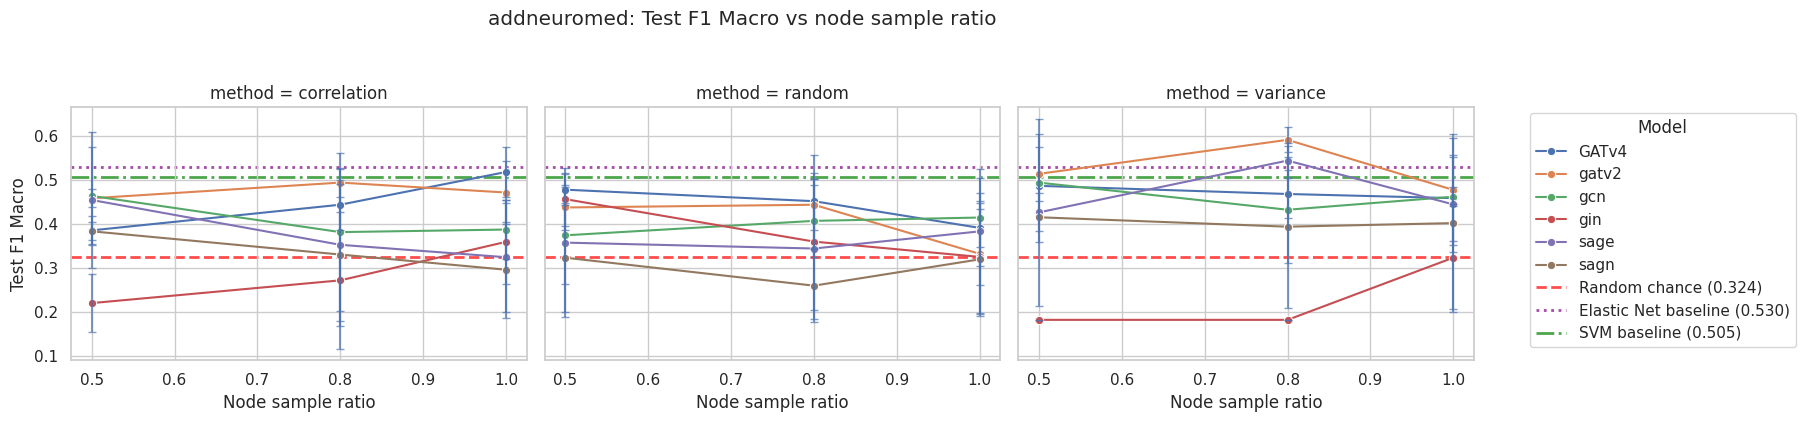

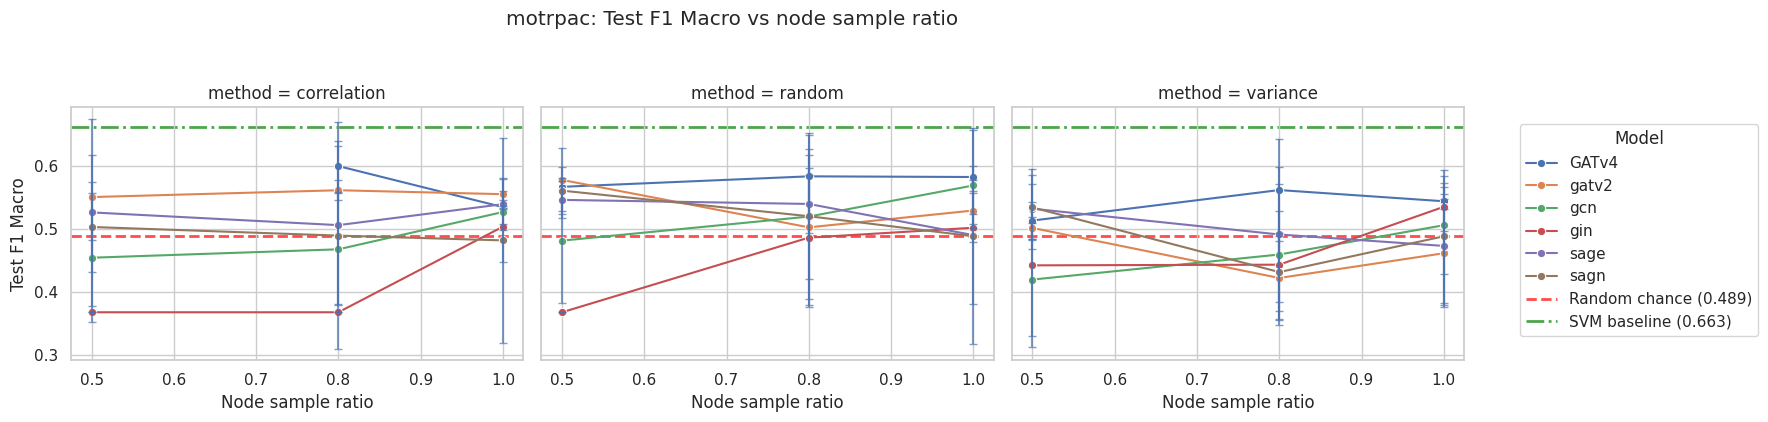

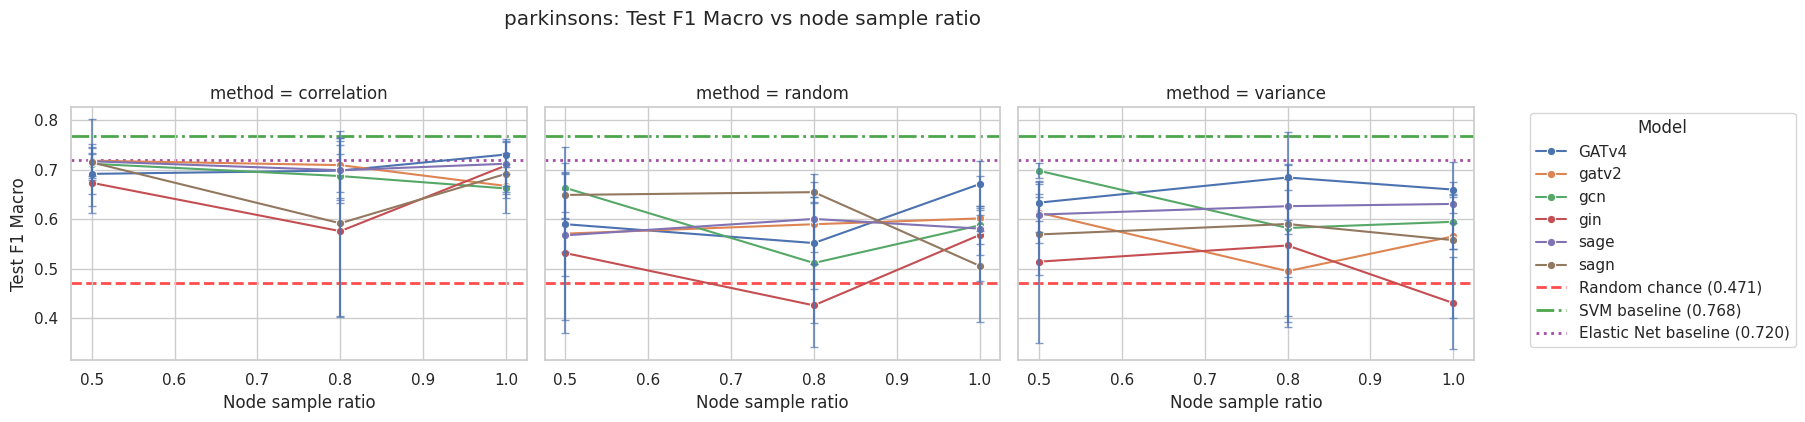

In [14]:
methods = ["correlation", "random", "variance"]

for data_name in sorted(agg_df["data_name"].dropna().unique()):
    sub_data = agg_df[agg_df["data_name"] == data_name].copy()
    if sub_data.empty:
        continue

    # Get random chance baseline for this dataset
    random_chance = random_chance_by_dataset.get(data_name, 0.5)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
    fig.suptitle(f"{data_name}: Test F1 Macro vs node sample ratio", y=1.05)

    # Get x-axis range from the data (for baseline lines)
    if not sub_data.empty:
        x_min = sub_data["node_sample_ratio"].min()
        x_max = sub_data["node_sample_ratio"].max()
    else:
        x_min, x_max = 0, 1

    for i, method in enumerate(methods):
        ax = axes[i]
        sub_m = sub_data[sub_data["method"] == method].copy()
        if sub_m.empty:
            ax.set_title(f"{method} (no data)")
            ax.axis("off")
            continue

        # Sort for nicer lines
        sub_m = sub_m.sort_values(["model_name", "node_sample_ratio"])

        # Line per model
        sns.lineplot(
            data=sub_m,
            x="node_sample_ratio",
            y="test_f1_macro",
            hue="model_name",
            marker="o",
            ax=ax,
        )

        # Error bars per (model, ratio)
        for (model_name), grp in sub_m.groupby("model_name"):
            ax.errorbar(
                grp["node_sample_ratio"],
                grp["test_f1_macro"],
                yerr=grp["test_f1_macro_std"],
                fmt="none",
                capsize=3,
                alpha=0.7,
            )



        # Add random chance baseline (without label - we'll add it to legend manually)
        xlim = ax.get_xlim()
        ax.axhline(
            y=random_chance,
            color="red",
            linestyle="--",
            linewidth=2,
            alpha=0.7,
            zorder=0,  # Draw behind other elements
        )
        
        # Add hardcoded baseline lines for SVM and Elastic Net
        baseline_values = {}
        if data_name == "addneuromed":
            baseline_values["Elastic Net"] = 0.5297
            baseline_values["SVM"] = 0.50524
        elif data_name == "motrpac":
            baseline_values["SVM"] = 0.66287
        elif data_name == "parkinsons":
            baseline_values["SVM"] = 0.76812
            baseline_values["Elastic Net"] = 0.72048
        
        # Plot baseline lines with different colors/styles
        baseline_colors = {"SVM": "green", "Elastic Net": "purple"}
        baseline_styles = {"SVM": "-.", "Elastic Net": ":"}
        for baseline_name, baseline_value in baseline_values.items():
            ax.axhline(
                y=baseline_value,
                color=baseline_colors[baseline_name],
                linestyle=baseline_styles[baseline_name],
                linewidth=2,
                alpha=0.7,
                zorder=0,  # Draw behind other elements
            )
        
        ax.set_xlim(xlim)

        ax.set_title(f"method = {method}")
        ax.set_xlabel("Node sample ratio")
        if i == 0:
            ax.set_ylabel("Test F1 Macro")
        else:
            ax.set_ylabel("")
        
        # Remove individual plot legends - we'll add one shared legend at the end
        if ax.legend_:
            ax.legend_.remove()

    # Remove legends from all axes first, then collect handles/labels from first axis
    for ax in axes:
        if ax.legend_:
            ax.legend_.remove()
    
    handles, labels = axes[0].get_legend_handles_labels()
    
    # Filter out any random chance lines that might have been included (shouldn't be, but just in case)
    filtered_handles = []
    filtered_labels = []
    for h, l in zip(handles, labels):
        # Skip if it looks like a random chance line (red dashed line)
        if hasattr(h, 'get_color') and hasattr(h, 'get_linestyle'):
            if h.get_color() == 'red' and h.get_linestyle() == '--':
                continue
        filtered_handles.append(h)
        filtered_labels.append(l)
    
    handles, labels = filtered_handles, filtered_labels
    
    # Add random chance baseline to legend (only once)
    from matplotlib.lines import Line2D
    random_line = Line2D([0], [0], color="red", linestyle="--", linewidth=2, alpha=0.7)
    handles.append(random_line)
    labels.append(f"Random chance ({random_chance:.3f})")
    
    # Add baseline lines to legend
    baseline_values = {}
    if data_name == "addneuromed":
        baseline_values["Elastic Net"] = 0.5297
        baseline_values["SVM"] = 0.50524
    elif data_name == "motrpac":
        baseline_values["SVM"] = 0.66287
    elif data_name == "parkinsons":
        baseline_values["SVM"] = 0.76812
        baseline_values["Elastic Net"] = 0.72048
    
    baseline_colors = {"SVM": "green", "Elastic Net": "purple"}
    baseline_styles = {"SVM": "-.", "Elastic Net": ":"}
    for baseline_name, baseline_value in baseline_values.items():
        baseline_line = Line2D(
            [0], [0],
            color=baseline_colors[baseline_name],
            linestyle=baseline_styles[baseline_name],
            linewidth=2,
            alpha=0.7
        )
        handles.append(baseline_line)
        labels.append(f"{baseline_name} baseline ({baseline_value:.3f})")
    
    # Put single legend outside on the right
    fig.legend(handles, labels, title="Model", bbox_to_anchor=(1.02, 0.5), loc="center left")
    plt.tight_layout()
    plt.show()
    

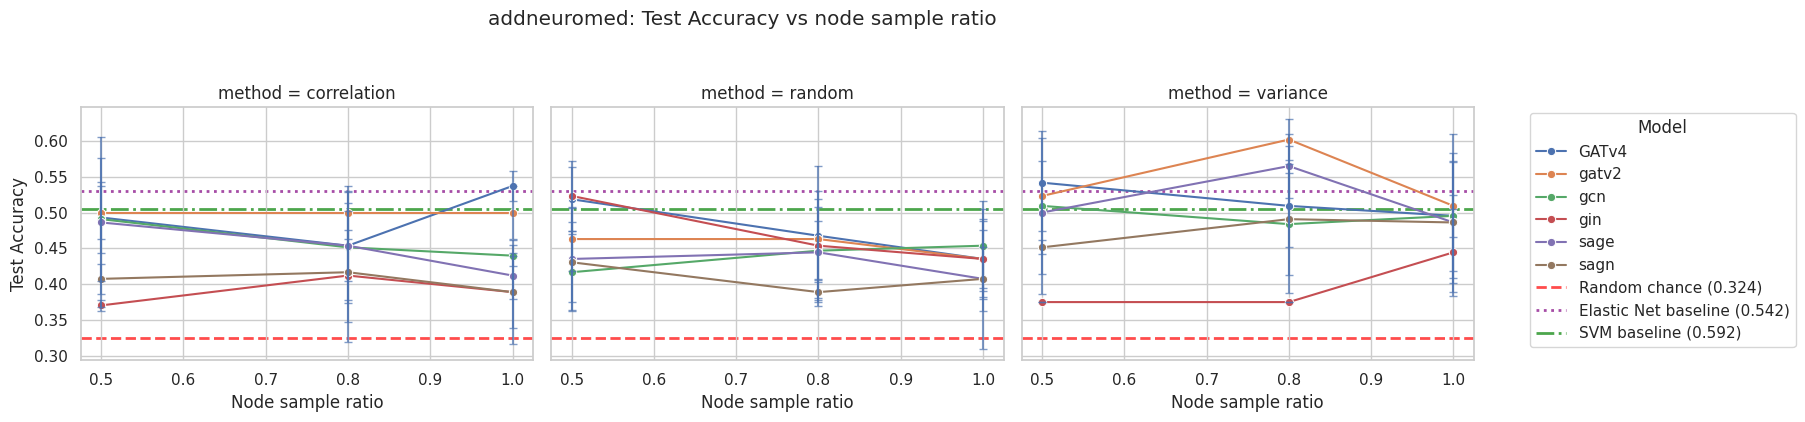

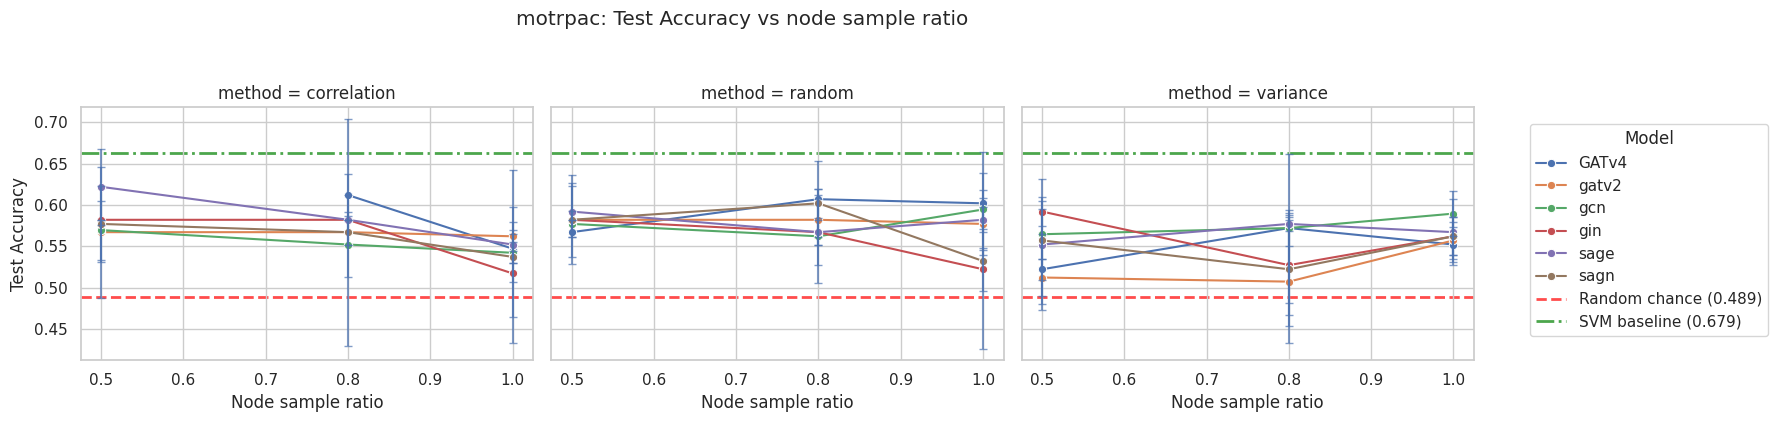

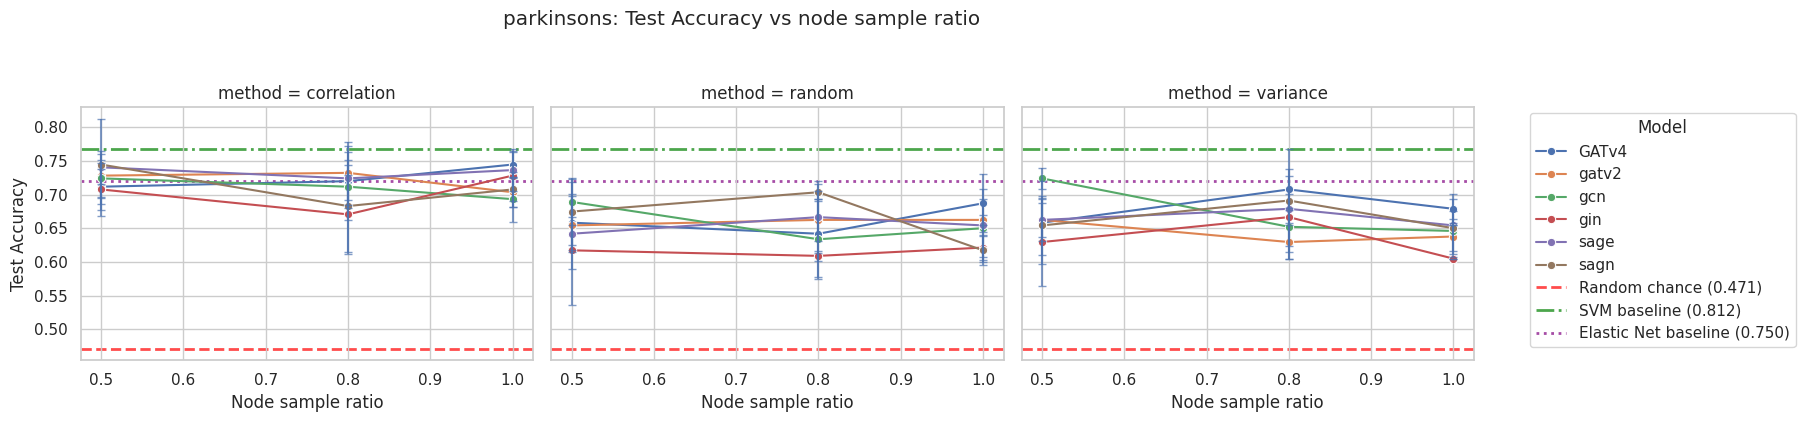

In [21]:
# ============================================================================
# ACCURACY PLOTS: Dataset-wise (same structure as F1 macro plots)
# ============================================================================
methods = ["correlation", "random", "variance"]

for data_name in sorted(agg_df["data_name"].dropna().unique()):
    sub_data = agg_df[agg_df["data_name"] == data_name].copy()
    if sub_data.empty:
        continue

    # Get random chance baseline for accuracy
    random_chance_accuracy = random_chance_accuracy_by_dataset.get(data_name, 0.5)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
    fig.suptitle(f"{data_name}: Test Accuracy vs node sample ratio", y=1.05)

    # Get x-axis range from the data (for baseline lines)
    if not sub_data.empty:
        x_min = sub_data["node_sample_ratio"].min()
        x_max = sub_data["node_sample_ratio"].max()
    else:
        x_min, x_max = 0, 1

    for i, method in enumerate(methods):
        ax = axes[i]
        sub_m = sub_data[sub_data["method"] == method].copy()
        if sub_m.empty:
            ax.set_title(f"{method} (no data)")
            ax.axis("off")
            continue

        # Sort for nicer lines
        sub_m = sub_m.sort_values(["model_name", "node_sample_ratio"])

        # Line per model
        sns.lineplot(
            data=sub_m,
            x="node_sample_ratio",
            y="test_accuracy",
            hue="model_name",
            marker="o",
            ax=ax,
        )

        # Error bars per (model, ratio)
        for (model_name), grp in sub_m.groupby("model_name"):
            ax.errorbar(
                grp["node_sample_ratio"],
                grp["test_accuracy"],
                yerr=grp["test_accuracy_std"],
                fmt="none",
                capsize=3,
                alpha=0.7,
            )

        # Add random chance baseline
        xlim = ax.get_xlim()
        ax.axhline(
            y=random_chance_accuracy,
            color="red",
            linestyle="--",
            linewidth=2,
            alpha=0.7,
            zorder=0,  # Draw behind other elements
        )
        
        # Add hardcoded baseline lines for SVM and Elastic Net (same as F1 macro)
        baseline_values = {}
        if data_name == "addneuromed":
            baseline_values["Elastic Net"] = 0.5297
            baseline_values["SVM"] = 0.50524
        elif data_name == "motrpac":
            baseline_values["SVM"] = 0.66287
        elif data_name == "parkinsons":
            baseline_values["SVM"] = 0.76812
            baseline_values["Elastic Net"] = 0.72048
        
        # Plot baseline lines with different colors/styles
        baseline_colors = {"SVM": "green", "Elastic Net": "purple"}
        baseline_styles = {"SVM": "-.", "Elastic Net": ":"}
        for baseline_name, baseline_value in baseline_values.items():
            ax.axhline(
                y=baseline_value,
                color=baseline_colors[baseline_name],
                linestyle=baseline_styles[baseline_name],
                linewidth=2,
                alpha=0.7,
                zorder=0,  # Draw behind other elements
            )
        
        ax.set_xlim(xlim)

        ax.set_title(f"method = {method}")
        ax.set_xlabel("Node sample ratio")
        if i == 0:
            ax.set_ylabel("Test Accuracy")
        else:
            ax.set_ylabel("")
        
        # Remove individual plot legends - we'll add one shared legend at the end
        if ax.legend_:
            ax.legend_.remove()

    # Remove legends from all axes first, then collect handles/labels from first axis
    for ax in axes:
        if ax.legend_:
            ax.legend_.remove()
    
    handles, labels = axes[0].get_legend_handles_labels()
    
    # Filter out any random chance lines that might have been included
    filtered_handles = []
    filtered_labels = []
    for h, l in zip(handles, labels):
        # Skip if it looks like a random chance line (red dashed line)
        if hasattr(h, 'get_color') and hasattr(h, 'get_linestyle'):
            if h.get_color() == 'red' and h.get_linestyle() == '--':
                continue
        filtered_handles.append(h)
        filtered_labels.append(l)
    
    handles, labels = filtered_handles, filtered_labels
    
    # Add random chance baseline to legend (only once)
    from matplotlib.lines import Line2D
    random_line = Line2D([0], [0], color="red", linestyle="--", linewidth=2, alpha=0.7)
    handles.append(random_line)
    labels.append(f"Random chance ({random_chance_accuracy:.3f})")
    
    # Add baseline lines to legend
    baseline_values = {}
    if data_name == "addneuromed":
        baseline_values["Elastic Net"] = 0.5422
        baseline_values["SVM"] = 0.5916
    elif data_name == "motrpac":
        baseline_values["SVM"] = 0.6793
    elif data_name == "parkinsons":
        baseline_values["SVM"] = 0.8125
        baseline_values["Elastic Net"] = 0.75
    
    baseline_colors = {"SVM": "green", "Elastic Net": "purple"}
    baseline_styles = {"SVM": "-.", "Elastic Net": ":"}
    for baseline_name, baseline_value in baseline_values.items():
        baseline_line = Line2D(
            [0], [0],
            color=baseline_colors[baseline_name],
            linestyle=baseline_styles[baseline_name],
            linewidth=2,
            alpha=0.7
        )
        handles.append(baseline_line)
        labels.append(f"{baseline_name} baseline ({baseline_value:.3f})")
    
    # Put single legend outside on the right
    fig.legend(handles, labels, title="Model", bbox_to_anchor=(1.02, 0.5), loc="center left")
    plt.tight_layout()
    plt.show()


In [16]:
# Helper function to calculate class weights from distribution
# Formula: weight[i] = N_samples / (num_classes * n_samples_for_class[i])
def calculate_class_weights_from_distribution(class_counts_dict, total_samples=None, num_classes=None):
    """
    Calculate class weights from class distribution using the formula:
    weight[i] = N_samples / (num_classes * n_samples_for_class[i])
    
    This matches the formula used in addneuromed config.
    """
    if total_samples is None:
        total_samples = sum(class_counts_dict.values())
    if num_classes is None:
        num_classes = len(class_counts_dict)
    
    calculated_weights = []
    for cls in sorted(class_counts_dict.keys()):
        cls_count = class_counts_dict[cls]
        weight = total_samples / (num_classes * cls_count)
        calculated_weights.append(weight)
    
    return calculated_weights

# Patch the calculate_random_chance_from_data function to auto-calculate class weights
# Save the original function
_original_calculate_random_chance = calculate_random_chance_from_data

def calculate_random_chance_from_data_with_auto_weights(data_name):
    """Wrapper that auto-calculates class weights if missing."""
    try:
        sub_df = df[df["data_name"] == data_name]
        
        # Get class weights from config (if present)
        class_weights = None
        if "dataset.parameters.class_weights" in df.columns:
            cw_series = sub_df["dataset.parameters.class_weights"].dropna()
            class_weights = cw_series.iloc[0] if len(cw_series) > 0 else None
        
        # Load targets to get class distribution
        revisions = sub_df.get("dataset.loader.parameters.revision", pd.Series()).dropna()
        revision = revisions.iloc[0] if len(revisions) > 0 else "9f052d330ce130408a2c7c347b2ed197154da7c8"
        targets, class_counts = load_dataset_targets(data_name, revision)
        
        if targets is None:
            return None
        
        # Calculate class weights if missing
        if class_weights is None or (isinstance(class_weights, str) and class_weights.strip() in {"__NaN__", "nan", "None", "null"}):
            if class_counts:
                class_weights = calculate_class_weights_from_distribution(
                    class_counts,
                    total_samples=len(targets),
                    num_classes=len(np.unique(targets))
                )
                print(f"  Auto-calculated class_weights from distribution: {class_weights}")
        
        # Now call original function but with calculated weights
        # We need to temporarily modify the df to include the calculated weights
        # Actually, let's just modify the function logic inline
                unique_classes, counts = np.unique(targets, return_counts=True)
        p_true = _normalize_probs(counts)
        
        # Calculate class_weights from class distribution if missing
        # Formula: weight[i] = N_samples / (num_classes * n_samples_for_class[i])
        if class_weights is None or (isinstance(class_weights, str) and class_weights.strip() in {"__NaN__", "nan", "None", "null"}):
            if class_counts:
                total_samples = len(targets)
                num_classes = len(unique_classes)
                calculated_weights = []
                for cls in sorted(unique_classes):
                    cls_count = int(counts[unique_classes == cls][0])
                    weight = total_samples / (num_classes * cls_count)
                    calculated_weights.append(weight)
                class_weights = calculated_weights

        # Predicted distribution p_pred (random classifier)
        if RANDOM_CHANCE_MODE == "uniform":
            p_pred = np.ones(len(unique_classes), dtype=float) / len(unique_classes)
        elif RANDOM_CHANCE_MODE == "class_weight":
            p_pred = _pred_probs_from_class_weights(class_weights, unique_classes)
        else:
            raise ValueError(f"Unknown RANDOM_CHANCE_MODE: {RANDOM_CHANCE_MODE}")
        
        # Expected macro-F1 of random predictions
        denom = p_true + p_pred
        f1_per_class = np.where(denom > 0, 2.0 * p_true * p_pred / denom, 0.0)
        random_chance = float(np.mean(f1_per_class))
        
        print(f"Random baseline (expected F1_macro) for {data_name}: {random_chance:.4f} (mode={RANDOM_CHANCE_MODE})")
        if class_counts:
            print(f"  Class distribution: {class_counts}")
        if RANDOM_CHANCE_MODE == "class_weight":
            if class_weights is None or (isinstance(class_weights, str) and class_weights.strip() in {"__NaN__", "nan", "None", "null"}):
                print("  class_weights missing/null for this dataset -> fell back to uniform p_pred")
            else:
                # Check if weights were auto-calculated (they would be a list/array)
                if isinstance(class_weights, (list, tuple, np.ndarray)) and len(class_weights) == len(unique_classes):
                    print(f"  Using class_weights: {class_weights}")
                else:
                    print(f"  Using class_weights: {class_weights}")
        
        return random_chance
        
    except Exception as e:
        print(f"Error calculating random chance for {data_name}: {e}")
        return None

# Replace the function
calculate_random_chance_from_data = calculate_random_chance_from_data_with_auto_weights


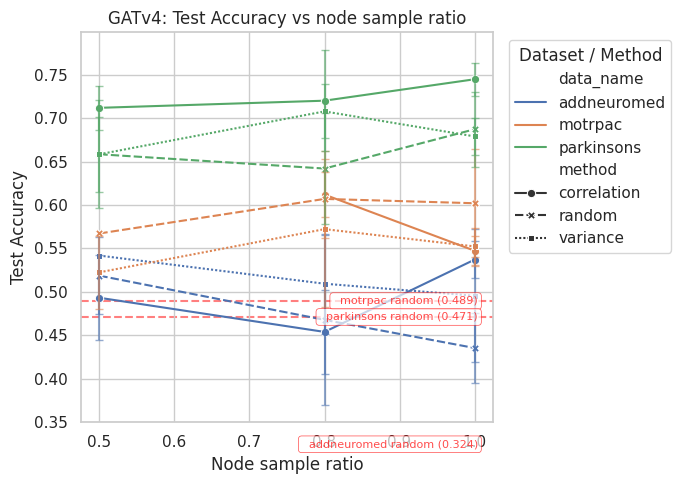

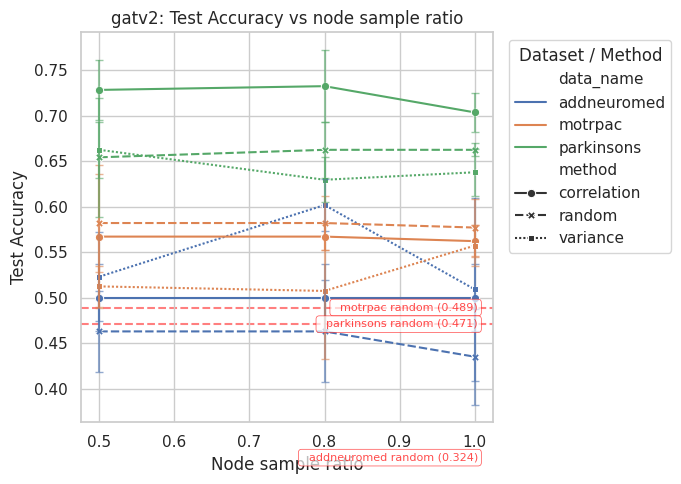

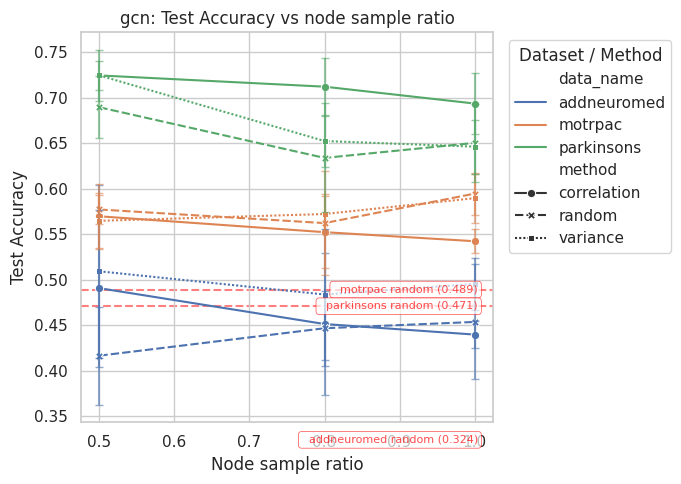

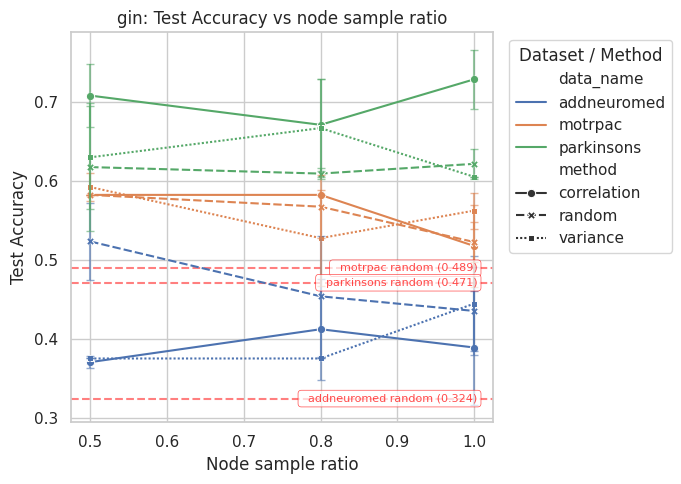

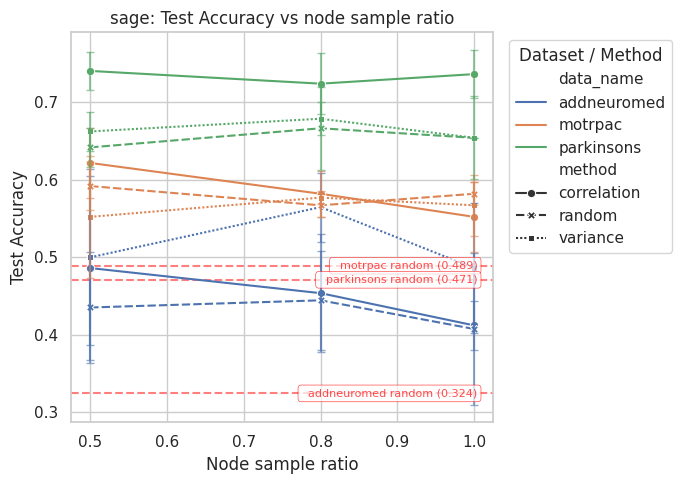

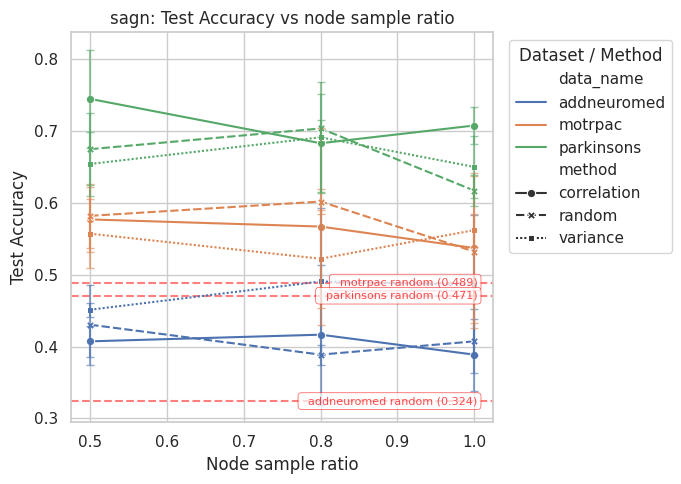

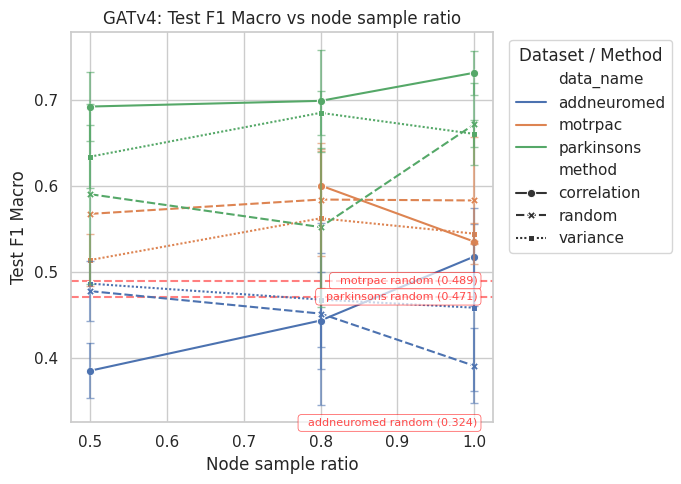

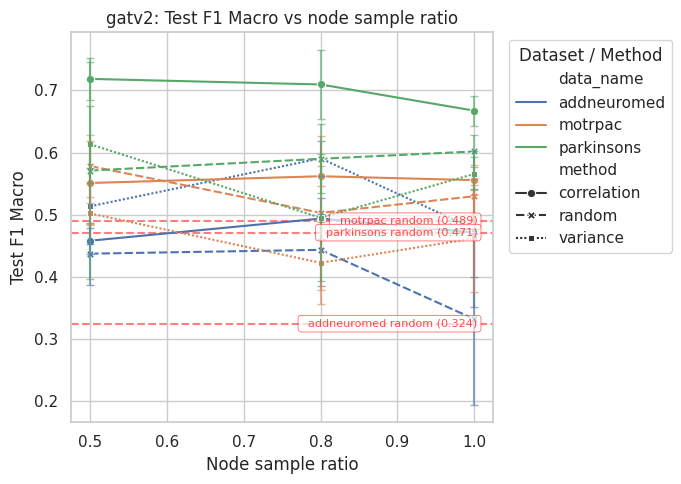

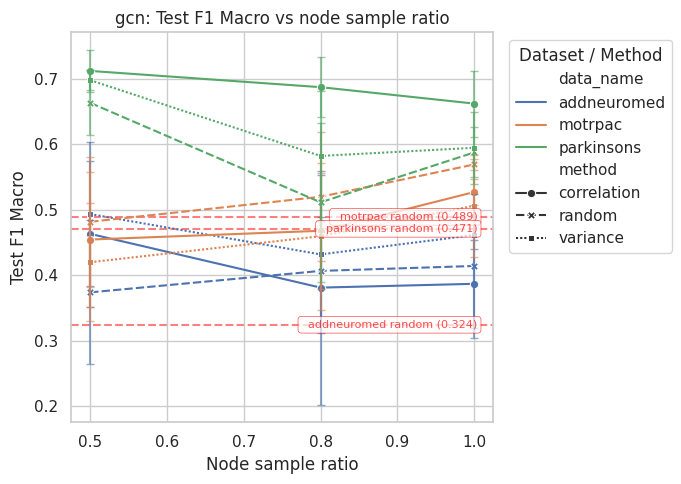

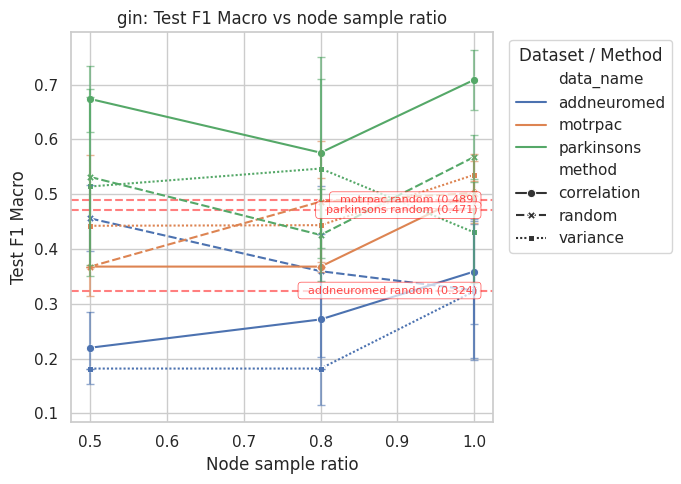

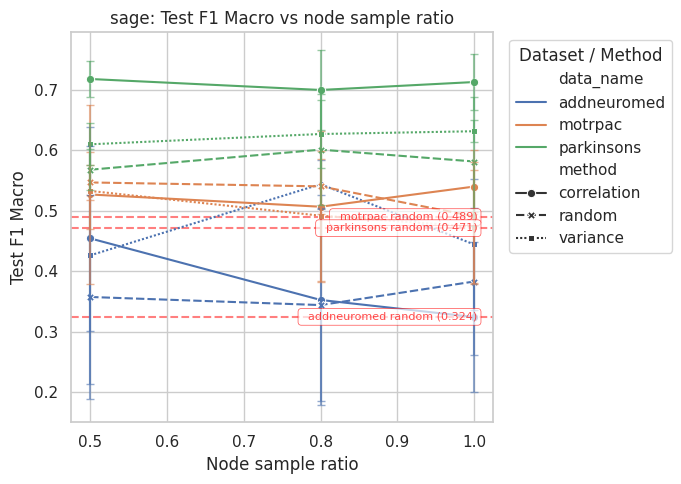

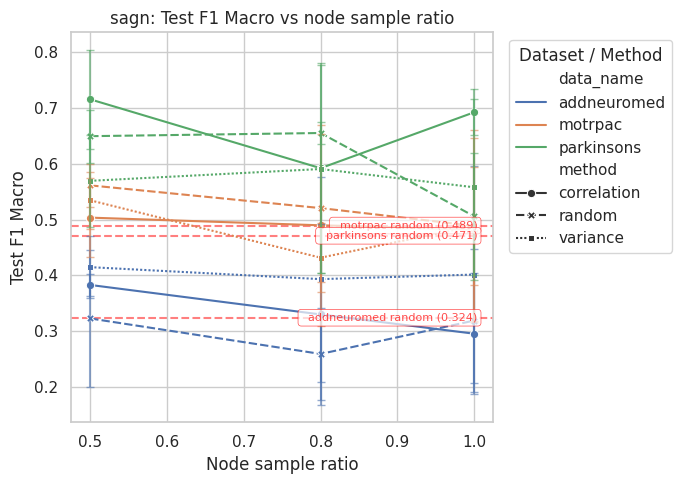

In [18]:
# Make sure ordering is clean and reproducible
dataset_order = ["addneuromed", "motrpac", "parkinsons"]
method_order = ["correlation", "random", "variance"]

for model_name in sorted(agg_df["model_name"].dropna().unique()):
    sub = agg_df[agg_df["model_name"] == model_name].copy()
    if sub.empty:
        continue

    sub = sub.sort_values(["data_name", "method", "node_sample_ratio"])

    plt.figure(figsize=(7, 5))
    
    ax = sns.lineplot(
        data=sub,
        x="node_sample_ratio",
        y="test_f1_macro",
        hue="data_name",        # <-- color = dataset
        style="method",         # <-- line style = method
        markers=True,
        dashes=True,
        hue_order=dataset_order,
        style_order=method_order,
    )

    # Add error bars per (data_name, method)
    for (data_name, method), grp in sub.groupby(["data_name", "method"]):
        ax.errorbar(
            grp["node_sample_ratio"],
            grp["test_f1_macro"],
            yerr=grp["test_f1_macro_std"],
            fmt="none",
            capsize=3,
            alpha=0.6,
            color=sns.color_palette()[dataset_order.index(data_name)],  # match color
        )

    # Add random chance baselines for each dataset
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    for data_name in sub["data_name"].dropna().unique():
        random_chance = random_chance_by_dataset.get(data_name, 0.5)
        ax.axhline(
            y=random_chance,
            color="red",
            linestyle="--",
            linewidth=1.5,
            alpha=0.5,
            zorder=0,  # Draw behind other elements
        )
        # Add text label
        ax.text(
            xlim[1] * 0.98,
            random_chance,
            f"  {data_name} random ({random_chance:.3f})",
            ha="right",
            va="center",
            fontsize=8,
            color="red",
            alpha=0.7,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7, edgecolor="red", linewidth=0.5),
        )
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    ax.set_title(f"{model_name}: Test F1 Macro vs node sample ratio")
    ax.set_xlabel("Node sample ratio")
    ax.set_ylabel("Test F1 Macro")
    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        title="Dataset / Method"
    )
    plt.tight_layout()
    plt.show()

MODEL PERFORMANCE SUMMARY (sorted by avg F1 Macro above chance)
            test_f1_macro_mean  test_f1_macro_std  test_f1_macro_min  test_f1_macro_max  f1_above_chance_mean  f1_above_chance_std  f1_above_chance_min  at_or_below_chance_sum  below_chance_sum  total_experiments  pct_below_chance
model_name                                                                                                                                                                                                                            
gin                     0.4322             0.1346             0.1818             0.7089                0.0041               0.0996              -0.1425                      13                13                 27             48.15
sagn                    0.4869             0.1232             0.2594             0.7151                0.0588               0.0802              -0.0648                       8                 8                 27             29.63
gcn         

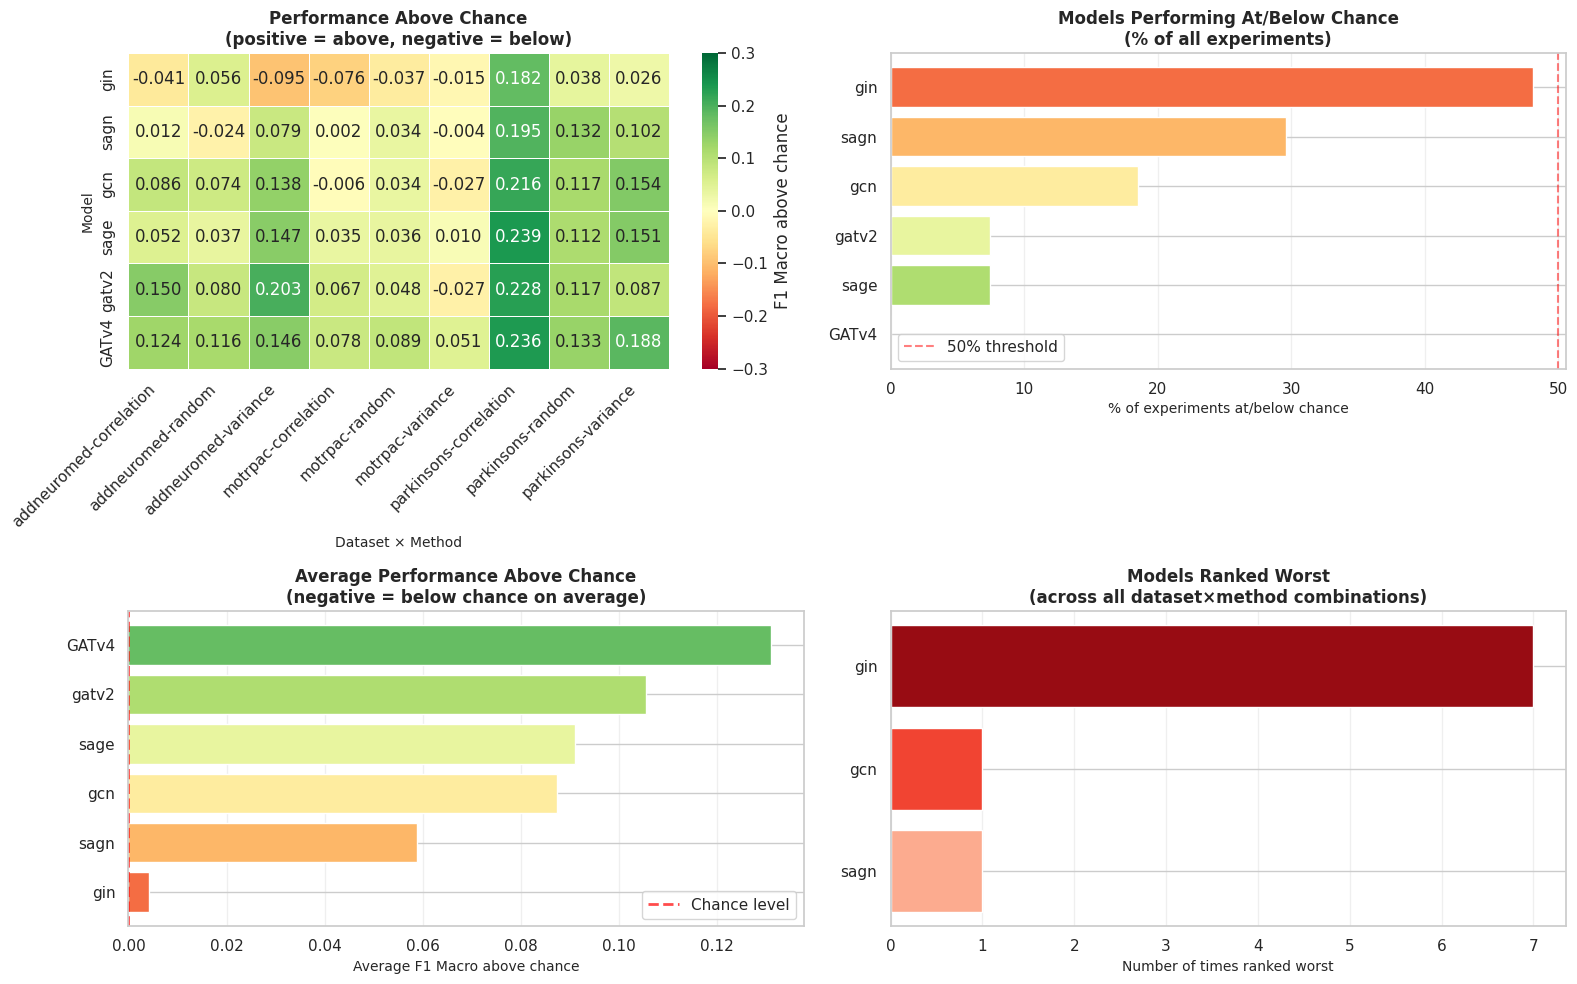


KEY FINDINGS:
Models that perform below chance in >50% of experiments:
  None

Models that rank worst most often:
  - sagn: worst in 1 dataset×method combinations
  - gcn: worst in 1 dataset×method combinations
  - gin: worst in 7 dataset×method combinations

Models with negative average performance above chance:
  None


In [19]:
# ============================================================================
# VISUALIZATION: Which models consistently perform worst or at/below chance?
# ============================================================================

# Add random chance baseline to each row
agg_df["random_chance"] = agg_df["data_name"].map(random_chance_by_dataset)
agg_df["above_chance"] = agg_df["test_f1_macro"] > agg_df["random_chance"]
agg_df["below_chance"] = agg_df["test_f1_macro"] < agg_df["random_chance"]
agg_df["at_or_below_chance"] = agg_df["test_f1_macro"] <= agg_df["random_chance"]
agg_df["f1_above_chance"] = agg_df["test_f1_macro"] - agg_df["random_chance"]

# Summary statistics per model
model_summary = agg_df.groupby("model_name").agg({
    "test_f1_macro": ["mean", "std", "min", "max"],
    "f1_above_chance": ["mean", "std", "min"],
    "at_or_below_chance": "sum",
    "below_chance": "sum",
}).round(4)

# Count total experiments per model
total_experiments = agg_df.groupby("model_name").size()

# Flatten column names first (handle MultiIndex)
if isinstance(model_summary.columns, pd.MultiIndex):
    model_summary.columns = ["_".join(col).strip() if col[1] else col[0] for col in model_summary.columns.values]

model_summary["total_experiments"] = total_experiments

# Calculate percentage below chance
model_summary["pct_below_chance"] = (
    model_summary["at_or_below_chance_sum"] / model_summary["total_experiments"] * 100
).round(2)

model_summary = model_summary.sort_values("f1_above_chance_mean")

print("=" * 80)
print("MODEL PERFORMANCE SUMMARY (sorted by avg F1 Macro above chance)")
print("=" * 80)
print(model_summary.to_string())
print("\n")

# Create visualization
fig = plt.figure(figsize=(16, 10))

# 1. Heatmap: Performance relative to chance across datasets and methods
ax1 = plt.subplot(2, 2, 1)
pivot_data = agg_df.pivot_table(
    values="f1_above_chance",
    index="model_name",
    columns=["data_name", "method"],
    aggfunc="mean"
)
# Sort by average performance
pivot_data = pivot_data.reindex(pivot_data.mean(axis=1).sort_values().index)
sns.heatmap(
    pivot_data,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    center=0,
    vmin=-0.3,
    vmax=0.3,
    cbar_kws={"label": "F1 Macro above chance"},
    ax=ax1,
    linewidths=0.5,
)
ax1.set_title("Performance Above Chance\n(positive = above, negative = below)", fontsize=12, fontweight="bold")
ax1.set_xlabel("Dataset × Method", fontsize=10)
ax1.set_ylabel("Model", fontsize=10)
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

# 2. Bar chart: Percentage of experiments where model performs at/below chance
ax2 = plt.subplot(2, 2, 2)
below_chance_pct = model_summary["pct_below_chance"].sort_values(ascending=True)
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(below_chance_pct)))
bars = ax2.barh(range(len(below_chance_pct)), below_chance_pct.values, color=colors)
ax2.set_yticks(range(len(below_chance_pct)))
ax2.set_yticklabels(below_chance_pct.index)
ax2.set_xlabel("% of experiments at/below chance", fontsize=10)
ax2.set_title("Models Performing At/Below Chance\n(% of all experiments)", fontsize=12, fontweight="bold")
ax2.axvline(x=50, color="red", linestyle="--", alpha=0.5, label="50% threshold")
ax2.legend()
ax2.grid(axis="x", alpha=0.3)

# 3. Bar chart: Average performance above chance per model
ax3 = plt.subplot(2, 2, 3)
avg_above_chance = model_summary["f1_above_chance_mean"].sort_values(ascending=True)
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(avg_above_chance)))
bars = ax3.barh(range(len(avg_above_chance)), avg_above_chance.values, color=colors)
ax3.set_yticks(range(len(avg_above_chance)))
ax3.set_yticklabels(avg_above_chance.index)
ax3.set_xlabel("Average F1 Macro above chance", fontsize=10)
ax3.set_title("Average Performance Above Chance\n(negative = below chance on average)", fontsize=12, fontweight="bold")
ax3.axvline(x=0, color="red", linestyle="--", linewidth=2, alpha=0.7, label="Chance level")
ax3.legend()
ax3.grid(axis="x", alpha=0.3)

# 4. Count of times each model ranks worst (across dataset×method combinations)
ax4 = plt.subplot(2, 2, 4)
worst_counts = {}
for (data_name, method), group in agg_df.groupby(["data_name", "method"]):
    if len(group) > 0:
        worst_model = group.loc[group["test_f1_macro"].idxmin(), "model_name"]
        worst_counts[worst_model] = worst_counts.get(worst_model, 0) + 1

worst_df = pd.Series(worst_counts).sort_values(ascending=True)
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(worst_df)))
bars = ax4.barh(range(len(worst_df)), worst_df.values, color=colors)
ax4.set_yticks(range(len(worst_df)))
ax4.set_yticklabels(worst_df.index)
ax4.set_xlabel("Number of times ranked worst", fontsize=10)
ax4.set_title("Models Ranked Worst\n(across all dataset×method combinations)", fontsize=12, fontweight="bold")
ax4.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("KEY FINDINGS:")
print("=" * 80)
print(f"Models that perform below chance in >50% of experiments:")
below_50 = model_summary[model_summary["pct_below_chance"] > 50]
if len(below_50) > 0:
    for model, row in below_50.iterrows():
        print(f"  - {model}: {row['pct_below_chance']:.1f}% of experiments at/below chance")
else:
    print("  None")
    
print(f"\nModels that rank worst most often:")
if len(worst_df) > 0:
    top_worst = worst_df.tail(3)
    for model, count in top_worst.items():
        print(f"  - {model}: worst in {count} dataset×method combinations")
        
print(f"\nModels with negative average performance above chance:")
negative_avg = model_summary[model_summary["f1_above_chance_mean"] < 0]
if len(negative_avg) > 0:
    for model, row in negative_avg.iterrows():
        print(f"  - {model}: avg {row['f1_above_chance_mean']:.4f} above chance")
else:
    print("  None")

# ============================================================================
# DETAILED BREAKDOWN: Performance by dataset and method
# ============================================================================
print("\n" + "=" * 80)
print("DETAILED BREAKDOWN: Performance by Dataset and Method")
print("=" * 80)

# For each model, show performance breakdown by dataset and method
for model_name in sorted(agg_df["model_name"].dropna().unique()):
    model_data = agg_df[agg_df["model_name"] == model_name].copy()
    model_data["above_chance"] = model_data["test_f1_macro"] > model_data["random_chance"]
    model_data["below_chance"] = model_data["test_f1_macro"] < model_data["random_chance"]
    
    print(f"\n{model_name.upper()}:")
    print("-" * 60)
    
    # Overall stats
    total = len(model_data)
    below = model_data["below_chance"].sum()
    at_or_below = (model_data["test_f1_macro"] <= model_data["random_chance"]).sum()
    avg_f1 = model_data["test_f1_macro"].mean()
    avg_above_chance = model_data["f1_above_chance"].mean()
    
    print(f"  Overall: {at_or_below}/{total} ({100*at_or_below/total:.1f}%) at/below chance")
    print(f"  Average F1 Macro: {avg_f1:.4f} (avg above chance: {avg_above_chance:.4f})")
    
    # Breakdown by dataset
    print(f"  By Dataset:")
    for data_name in sorted(model_data["data_name"].dropna().unique()):
        sub = model_data[model_data["data_name"] == data_name]
        random_chance = sub["random_chance"].iloc[0]
        below_count = (sub["test_f1_macro"] < random_chance).sum()
        at_or_below_count = (sub["test_f1_macro"] <= random_chance).sum()
        avg_f1_ds = sub["test_f1_macro"].mean()
        print(f"    {data_name}: {at_or_below_count}/{len(sub)} at/below chance, avg F1={avg_f1_ds:.4f} (chance={random_chance:.4f})")
    
    # Breakdown by method
    print(f"  By Method:")
    for method in sorted(model_data["method"].dropna().unique()):
        sub = model_data[model_data["method"] == method]
        below_count = sub["below_chance"].sum()
        at_or_below_count = (sub["test_f1_macro"] <= sub["random_chance"]).sum()
        avg_f1_method = sub["test_f1_macro"].mean()
        print(f"    {method}: {at_or_below_count}/{len(sub)} at/below chance, avg F1={avg_f1_method:.4f}")
    
    # Worst performing combinations
    model_data["f1_above_chance"] = model_data["test_f1_macro"] - model_data["random_chance"]
    worst_combos = model_data.nsmallest(3, "f1_above_chance")[["data_name", "method", "node_sample_ratio", "test_f1_macro", "f1_above_chance"]]
    if len(worst_combos) > 0:
        print(f"  Worst 3 combinations:")
        for idx, row in worst_combos.iterrows():
            print(f"    {row['data_name']} × {row['method']} × ratio={row['node_sample_ratio']:.2f}: F1={row['test_f1_macro']:.4f} (above chance: {row['f1_above_chance']:.4f})")


# Analysis: Consistently Worst-Performing GNN Models

## Summary of Findings

Based on the comprehensive analysis across three datasets (addneuromed, motrpac, parkinsons) and three node sampling methods (correlation, random, variance), **GIN (Graph Isomorphism Network) consistently emerges as the worst-performing model**, followed by SAGN (Structure-Aware Graph Network) and GCN (Graph Convolutional Network).

### Key Statistics



In [22]:
# ============================================================================
# ANALYSIS: Node Selection Method Comparison (Correlation vs Random vs Variance)
# ============================================================================

print("=" * 80)
print("NODE SELECTION METHOD COMPARISON")
print("=" * 80)

# Compare methods across all datasets and models
method_comparison = agg_df.groupby("method").agg({
    "test_f1_macro": ["mean", "std", "count"],
    "test_accuracy": ["mean", "std"],
}).round(4)

# Flatten column names
if isinstance(method_comparison.columns, pd.MultiIndex):
    method_comparison.columns = ["_".join(col).strip() if col[1] else col[0] for col in method_comparison.columns.values]

print("\nOverall Performance by Method:")
print(method_comparison.to_string())

# Compare methods per dataset
print("\n" + "=" * 80)
print("Performance by Method and Dataset:")
print("=" * 80)
for data_name in sorted(agg_df["data_name"].dropna().unique()):
    sub = agg_df[agg_df["data_name"] == data_name]
    method_stats = sub.groupby("method").agg({
        "test_f1_macro": ["mean", "std", "count"],
        "test_accuracy": ["mean", "std"],
    }).round(4)
    
    if isinstance(method_stats.columns, pd.MultiIndex):
        method_stats.columns = ["_".join(col).strip() if col[1] else col[0] for col in method_stats.columns.values]
    
    print(f"\n{data_name.upper()}:")
    print(method_stats.to_string())

# Compare methods per model
print("\n" + "=" * 80)
print("Performance by Method and Model:")
print("=" * 80)
for model_name in sorted(agg_df["model_name"].dropna().unique()):
    sub = agg_df[agg_df["model_name"] == model_name]
    method_stats = sub.groupby("method").agg({
        "test_f1_macro": ["mean", "std", "count"],
        "test_accuracy": ["mean", "std"],
    }).round(4)
    
    if isinstance(method_stats.columns, pd.MultiIndex):
        method_stats.columns = ["_".join(col).strip() if col[1] else col[0] for col in method_stats.columns.values]
    
    print(f"\n{model_name.upper()}:")
    print(method_stats.to_string())

# Statistical comparison: is correlation significantly better?
from scipy import stats

print("\n" + "=" * 80)
print("STATISTICAL COMPARISON: Correlation vs Others")
print("=" * 80)

for metric in ["test_f1_macro", "test_accuracy"]:
    print(f"\n{metric.upper()}:")
    correlation_scores = agg_df[agg_df["method"] == "correlation"][metric].dropna()
    random_scores = agg_df[agg_df["method"] == "random"][metric].dropna()
    variance_scores = agg_df[agg_df["method"] == "variance"][metric].dropna()
    
    # T-tests
    t_stat_corr_vs_random, p_val_corr_vs_random = stats.ttest_ind(correlation_scores, random_scores)
    t_stat_corr_vs_variance, p_val_corr_vs_variance = stats.ttest_ind(correlation_scores, variance_scores)
    
    print(f"  Correlation vs Random:")
    print(f"    Mean difference: {correlation_scores.mean() - random_scores.mean():.4f}")
    print(f"    T-statistic: {t_stat_corr_vs_random:.4f}, p-value: {p_val_corr_vs_random:.4f}")
    print(f"    {'Significant' if p_val_corr_vs_random < 0.05 else 'Not significant'} (α=0.05)")
    
    print(f"  Correlation vs Variance:")
    print(f"    Mean difference: {correlation_scores.mean() - variance_scores.mean():.4f}")
    print(f"    T-statistic: {t_stat_corr_vs_variance:.4f}, p-value: {p_val_corr_vs_variance:.4f}")
    print(f"    {'Significant' if p_val_corr_vs_variance < 0.05 else 'Not significant'} (α=0.05)")


NODE SELECTION METHOD COMPARISON

Overall Performance by Method:
             test_f1_macro_mean  test_f1_macro_std  test_f1_macro_count  test_accuracy_mean  test_accuracy_std
method                                                                                                        
correlation              0.5263             0.1402                   53              0.5784             0.1164
random                   0.4943             0.1016                   54              0.5584             0.0905
variance                 0.5010             0.1015                   54              0.5686             0.0803

Performance by Method and Dataset:

ADDNEUROMED:
             test_f1_macro_mean  test_f1_macro_std  test_f1_macro_count  test_accuracy_mean  test_accuracy_std
method                                                                                                        
correlation              0.3883             0.0815                   18              0.4501             0.04

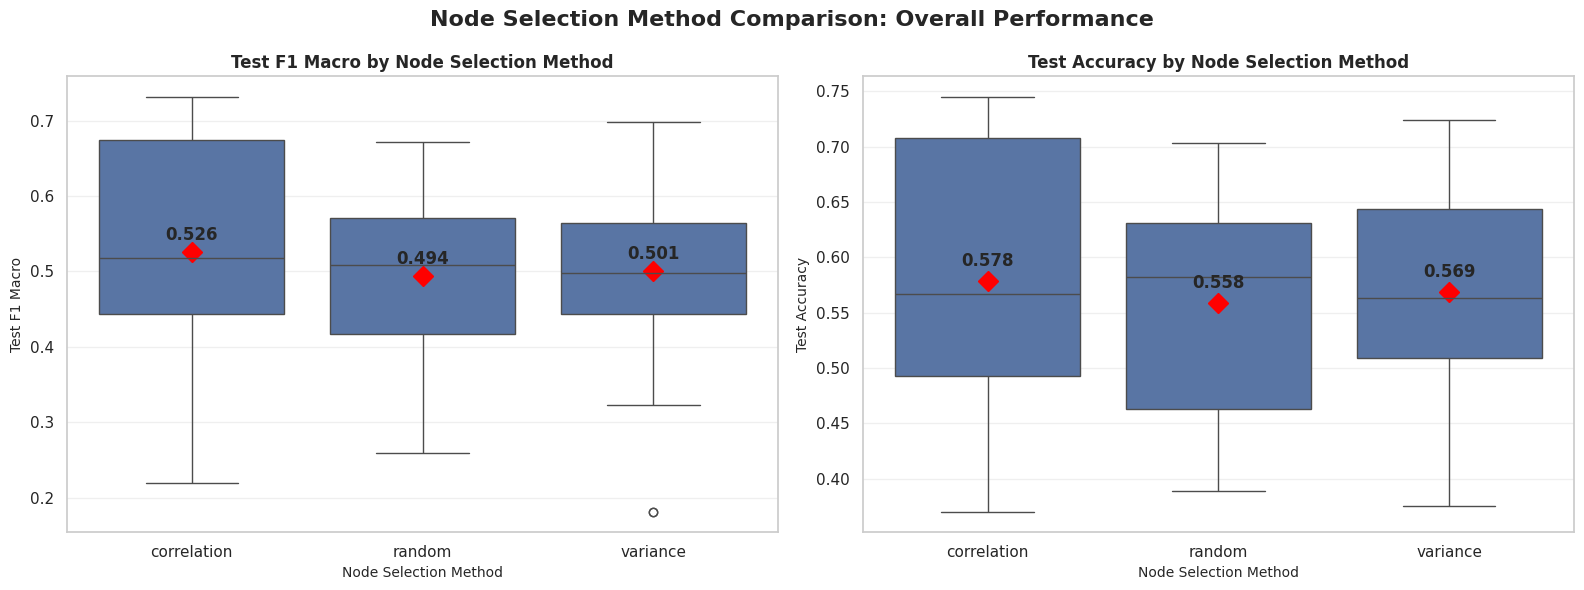

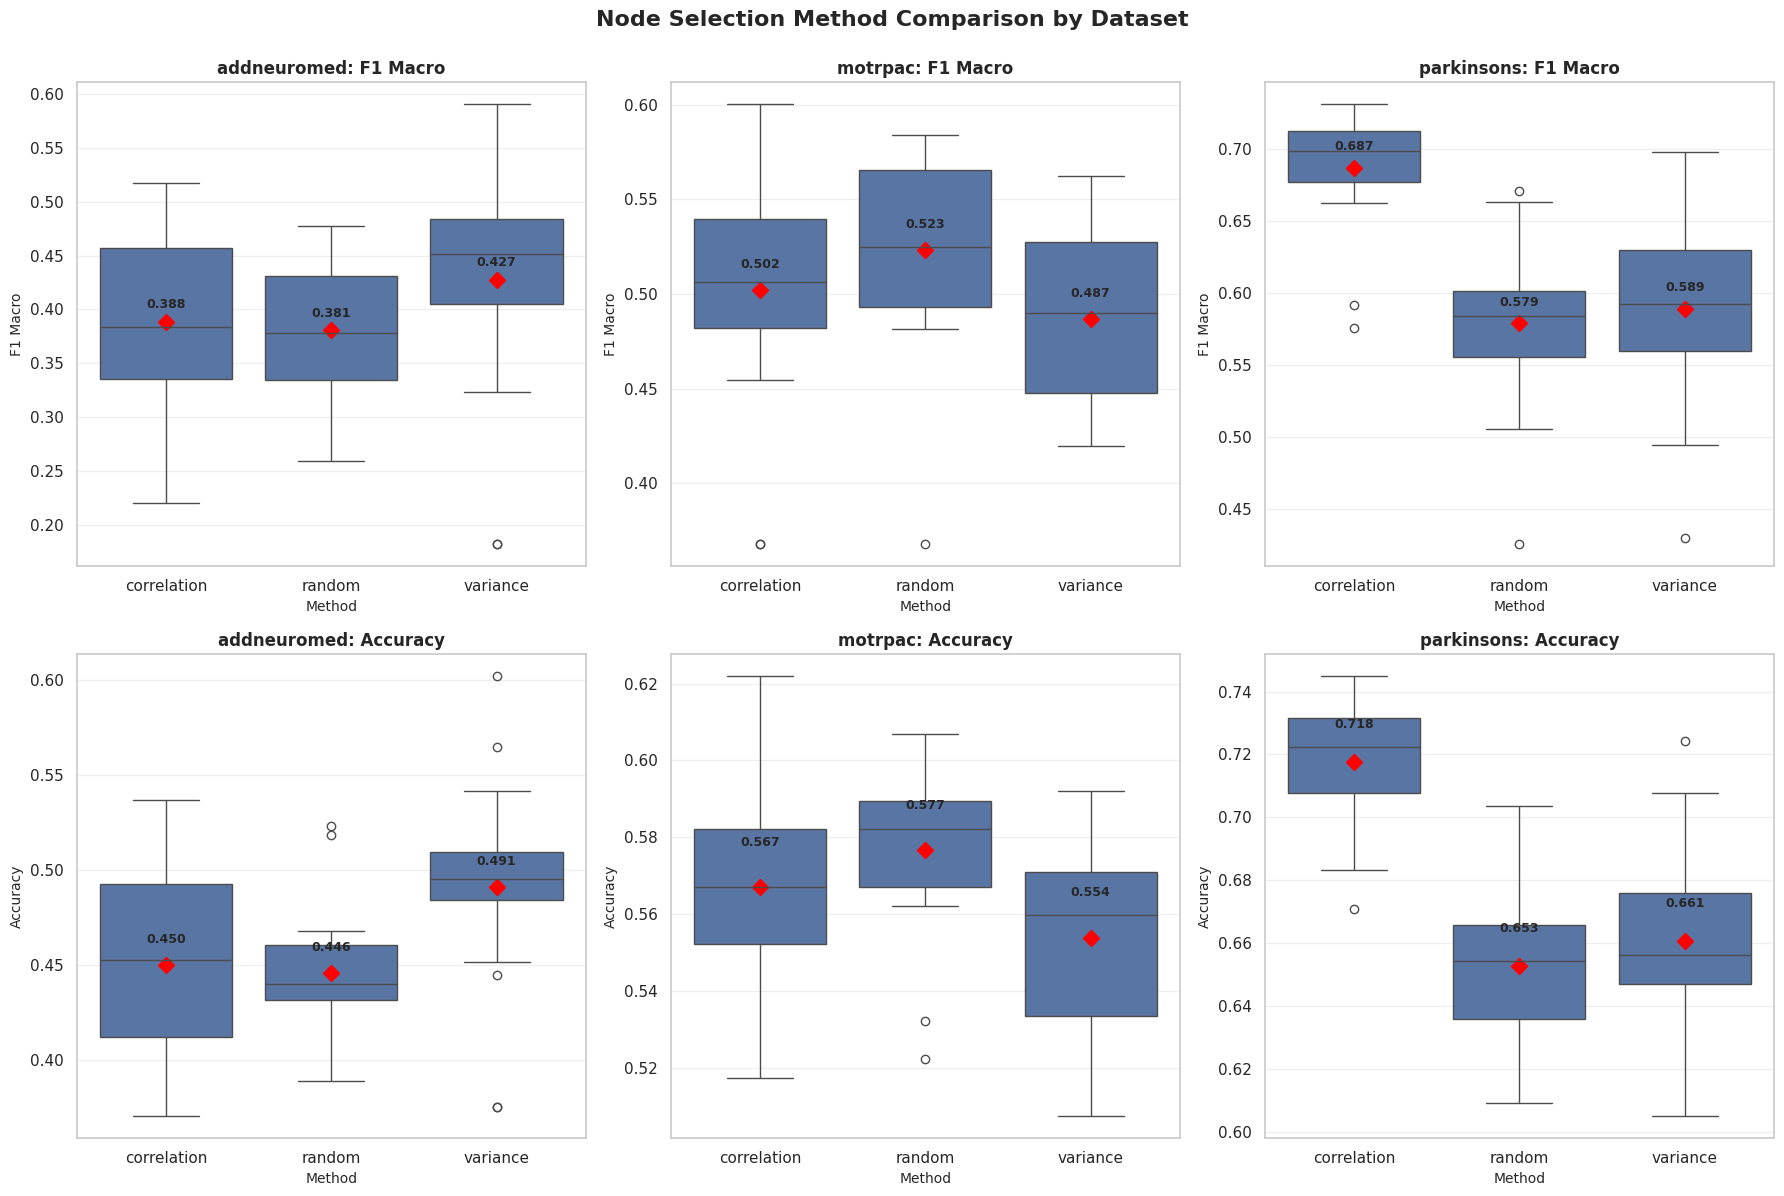

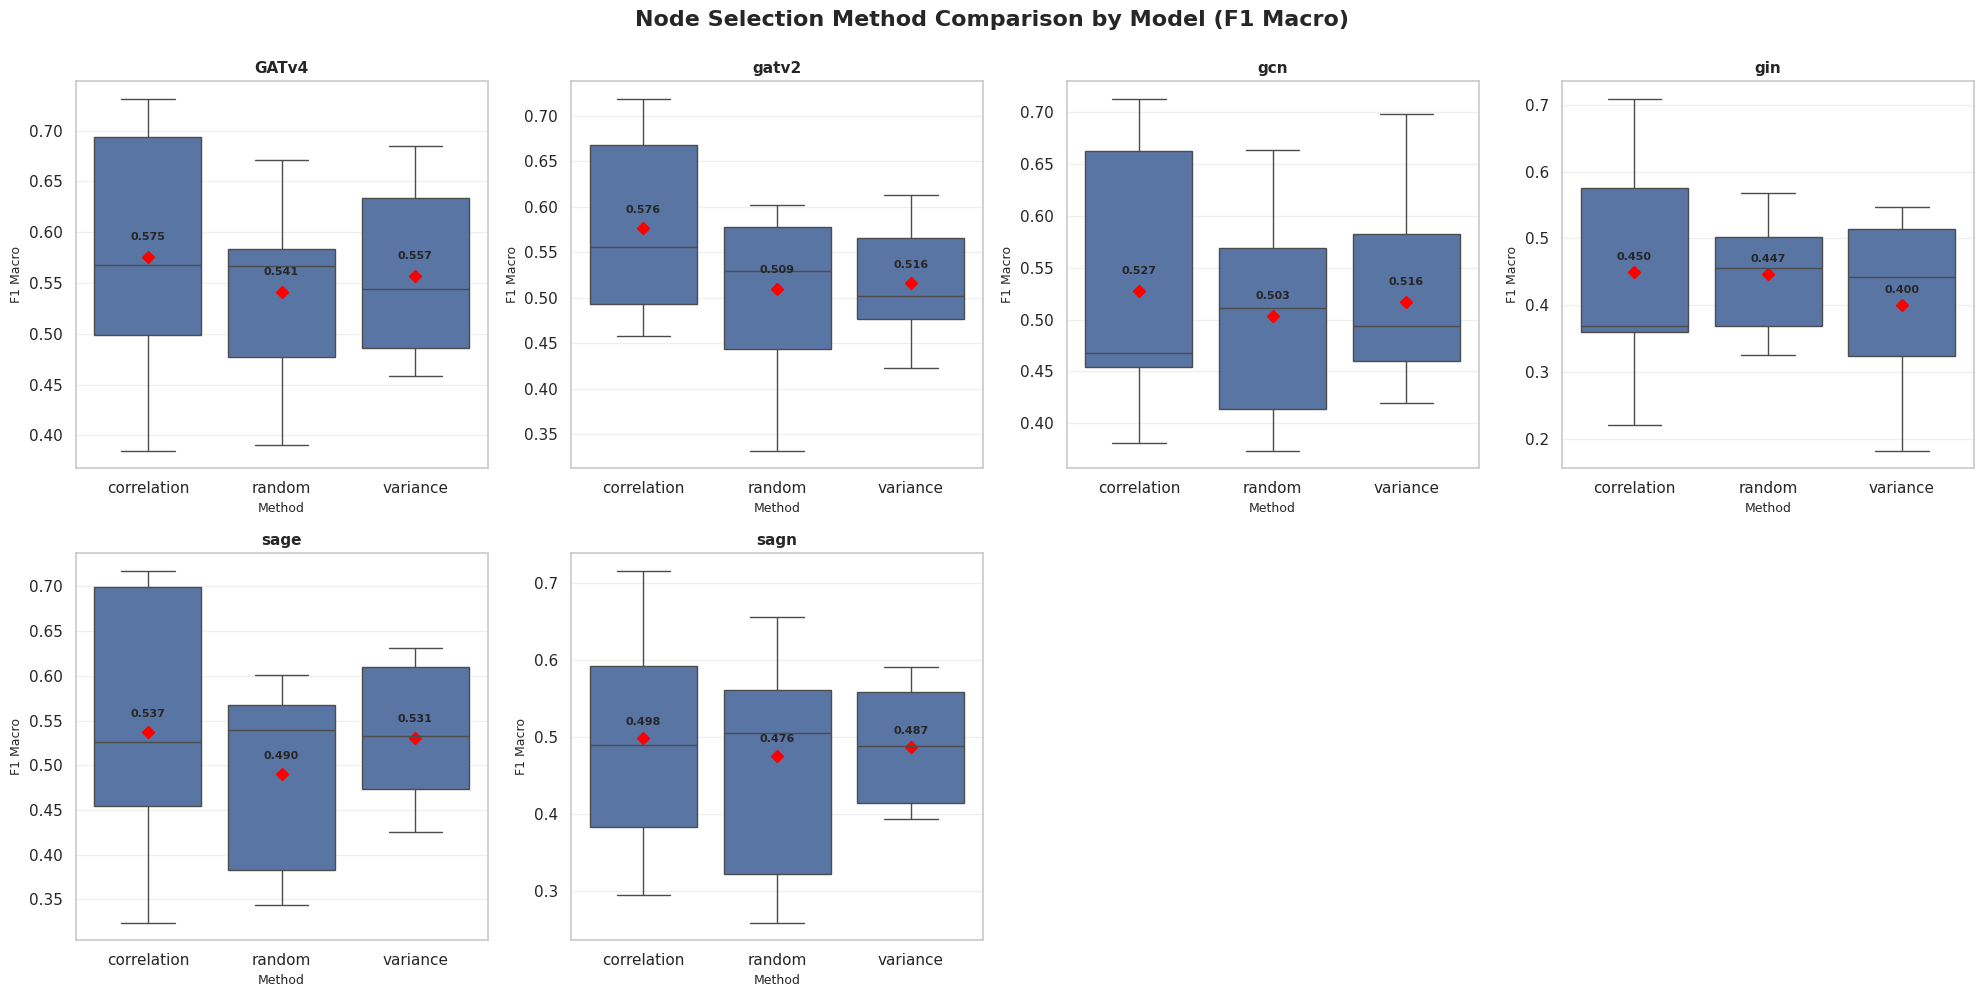

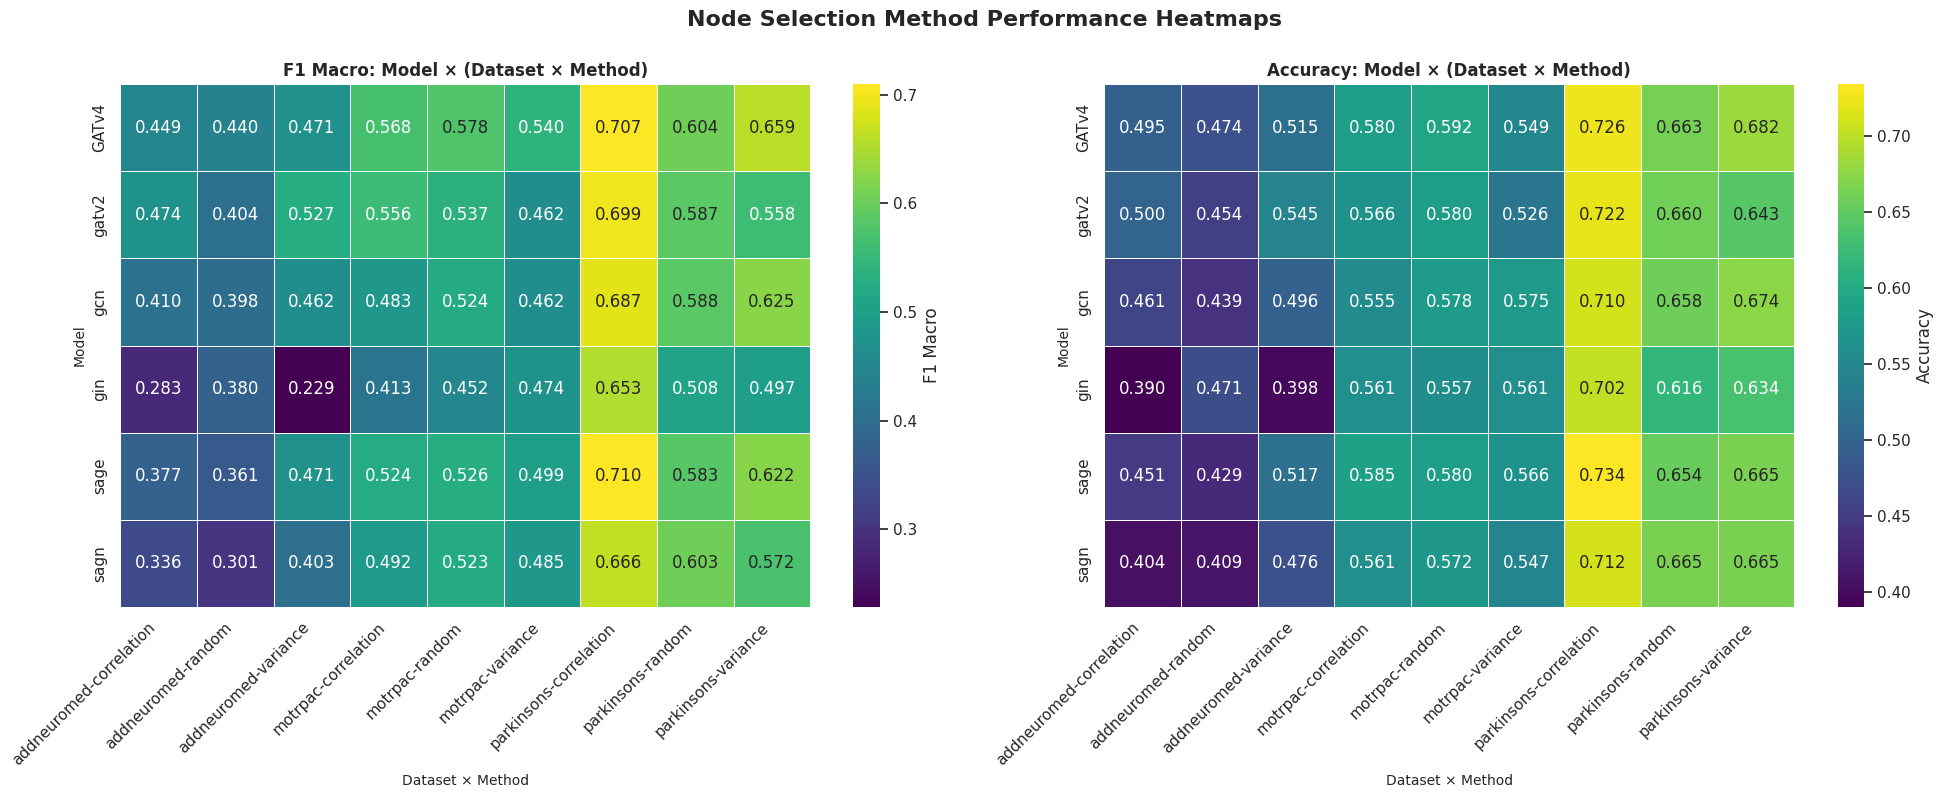

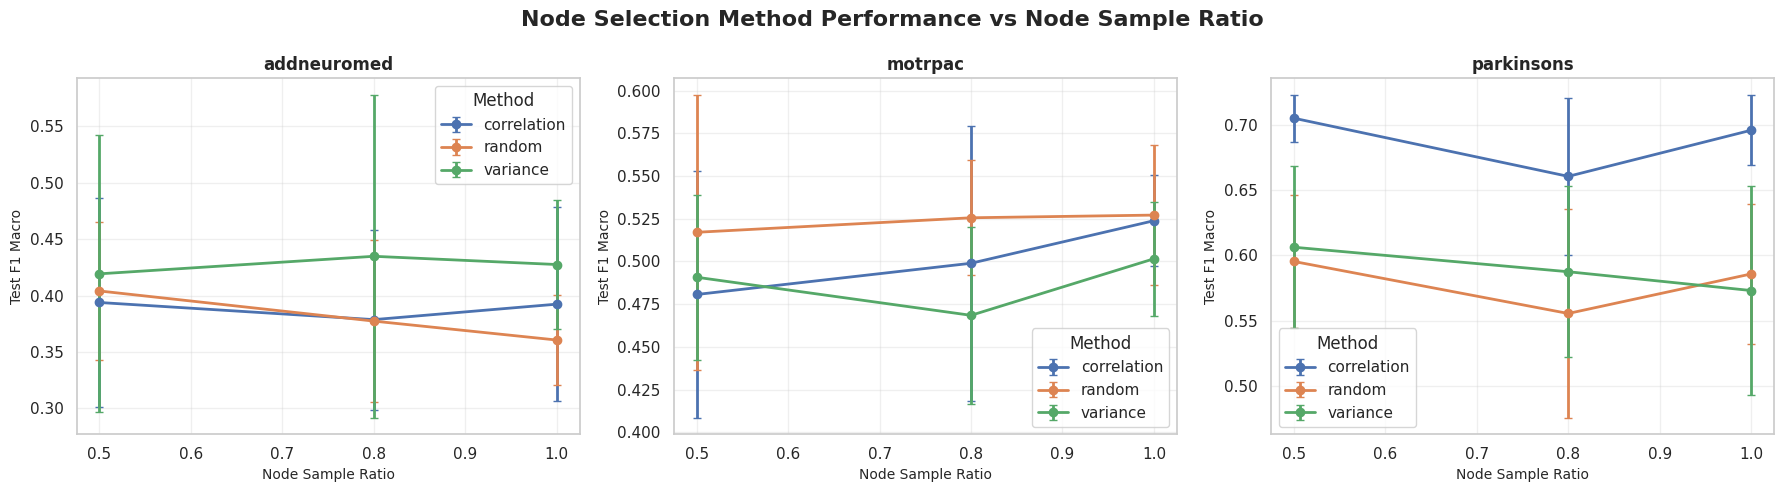

In [ ]:
# ============================================================================
# PLOTS: Node Selection Method Comparison
# ============================================================================

# 1. Overall comparison: Box plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Node Selection Method Comparison: Overall Performance", fontsize=16, fontweight="bold")

# F1 Macro
ax1 = axes[0]
method_order = ["correlation", "random", "variance"]
sns.boxplot(data=agg_df, x="method", y="test_f1_macro", order=method_order, ax=ax1)
ax1.set_title("Test F1 Macro by Node Selection Method", fontsize=12, fontweight="bold")
ax1.set_xlabel("Node Selection Method", fontsize=10)
ax1.set_ylabel("Test F1 Macro", fontsize=10)
ax1.grid(axis="y", alpha=0.3)

# Add mean markers
for i, method in enumerate(method_order):
    method_data = agg_df[agg_df["method"] == method]["test_f1_macro"].dropna()
    if len(method_data) > 0:
        mean_val = method_data.mean()
        ax1.plot(i, mean_val, marker="D", color="red", markersize=10, label="Mean" if i == 0 else "")
        ax1.text(i, mean_val + 0.01, f"{mean_val:.3f}", ha="center", va="bottom", fontweight="bold")

# Accuracy
ax2 = axes[1]
sns.boxplot(data=agg_df, x="method", y="test_accuracy", order=method_order, ax=ax2)
ax2.set_title("Test Accuracy by Node Selection Method", fontsize=12, fontweight="bold")
ax2.set_xlabel("Node Selection Method", fontsize=10)
ax2.set_ylabel("Test Accuracy", fontsize=10)
ax2.grid(axis="y", alpha=0.3)

# Add mean markers
for i, method in enumerate(method_order):
    method_data = agg_df[agg_df["method"] == method]["test_accuracy"].dropna()
    if len(method_data) > 0:
        mean_val = method_data.mean()
        ax2.plot(i, mean_val, marker="D", color="red", markersize=10, label="Mean" if i == 0 else "")
        ax2.text(i, mean_val + 0.01, f"{mean_val:.3f}", ha="center", va="bottom", fontweight="bold")

if ax1.legend_:
    ax1.legend_.remove()
if ax2.legend_:
    ax2.legend_.remove()

plt.tight_layout()
plt.show()

# 2. Comparison by dataset
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("Node Selection Method Comparison by Dataset", fontsize=16, fontweight="bold", y=0.995)

datasets = sorted(agg_df["data_name"].dropna().unique())
for i, data_name in enumerate(datasets):
    sub = agg_df[agg_df["data_name"] == data_name]
    
    # F1 Macro
    ax1 = axes[0, i]
    sns.boxplot(data=sub, x="method", y="test_f1_macro", order=method_order, ax=ax1)
    ax1.set_title(f"{data_name}: F1 Macro", fontsize=12, fontweight="bold")
    ax1.set_xlabel("Method", fontsize=10)
    ax1.set_ylabel("F1 Macro", fontsize=10)
    ax1.grid(axis="y", alpha=0.3)
    
    # Add mean markers
    for j, method in enumerate(method_order):
        method_data = sub[sub["method"] == method]["test_f1_macro"].dropna()
        if len(method_data) > 0:
            mean_val = method_data.mean()
            ax1.plot(j, mean_val, marker="D", color="red", markersize=8)
            ax1.text(j, mean_val + 0.01, f"{mean_val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    
    # Accuracy
    ax2 = axes[1, i]
    sns.boxplot(data=sub, x="method", y="test_accuracy", order=method_order, ax=ax2)
    ax2.set_title(f"{data_name}: Accuracy", fontsize=12, fontweight="bold")
    ax2.set_xlabel("Method", fontsize=10)
    ax2.set_ylabel("Accuracy", fontsize=10)
    ax2.grid(axis="y", alpha=0.3)
    
    # Add mean markers
    for j, method in enumerate(method_order):
        method_data = sub[sub["method"] == method]["test_accuracy"].dropna()
        if len(method_data) > 0:
            mean_val = method_data.mean()
            ax2.plot(j, mean_val, marker="D", color="red", markersize=8)
            ax2.text(j, mean_val + 0.01, f"{mean_val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

# 3. Comparison by model
models = sorted(agg_df["model_name"].dropna().unique())
n_models = len(models)
n_cols = 4
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
fig.suptitle("Node Selection Method Comparison by Model (F1 Macro)", fontsize=16, fontweight="bold", y=0.995)
axes = axes.flatten() if n_models > 1 else [axes]

for i, model_name in enumerate(models):
    ax = axes[i]
    sub = agg_df[agg_df["model_name"] == model_name]
    
    sns.boxplot(data=sub, x="method", y="test_f1_macro", order=method_order, ax=ax)
    ax.set_title(f"{model_name}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Method", fontsize=9)
    ax.set_ylabel("F1 Macro", fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    
    # Add mean markers
    for j, method in enumerate(method_order):
        method_data = sub[sub["method"] == method]["test_f1_macro"].dropna()
        if len(method_data) > 0:
            mean_val = method_data.mean()
            ax.plot(j, mean_val, marker="D", color="red", markersize=6)
            ax.text(j, mean_val + 0.015, f"{mean_val:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

# Hide unused subplots
for i in range(n_models, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

# 4. Heatmap: Method performance across dataset×model combinations
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle("Node Selection Method Performance Heatmaps", fontsize=16, fontweight="bold", y=0.995)

# F1 Macro heatmap
ax1 = axes[0]
pivot_f1 = agg_df.pivot_table(
    values="test_f1_macro",
    index="model_name",
    columns=["data_name", "method"],
    aggfunc="mean"
)
sns.heatmap(
    pivot_f1,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    ax=ax1,
    cbar_kws={"label": "F1 Macro"},
    linewidths=0.5,
)
ax1.set_title("F1 Macro: Model × (Dataset × Method)", fontsize=12, fontweight="bold")
ax1.set_xlabel("Dataset × Method", fontsize=10)
ax1.set_ylabel("Model", fontsize=10)
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

# Accuracy heatmap
ax2 = axes[1]
pivot_acc = agg_df.pivot_table(
    values="test_accuracy",
    index="model_name",
    columns=["data_name", "method"],
    aggfunc="mean"
)
sns.heatmap(
    pivot_acc,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    ax=ax2,
    cbar_kws={"label": "Accuracy"},
    linewidths=0.5,
)
ax2.set_title("Accuracy: Model × (Dataset × Method)", fontsize=12, fontweight="bold")
ax2.set_xlabel("Dataset × Method", fontsize=10)
ax2.set_ylabel("Model", fontsize=10)
plt.setp(ax2.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

# 5. Line plots: Method performance vs node sample ratio
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Node Selection Method Performance vs Node Sample Ratio", fontsize=16, fontweight="bold")

for i, data_name in enumerate(datasets):
    ax = axes[i]
    sub = agg_df[agg_df["data_name"] == data_name]
    
    for method in method_order:
        method_data = sub[sub["method"] == method].sort_values("node_sample_ratio")
        if len(method_data) > 0:
            # Group by ratio and calculate mean/std
            grouped = method_data.groupby("node_sample_ratio").agg({
                "test_f1_macro": ["mean", "std"],
            })
            grouped.columns = ["mean", "std"]
            grouped = grouped.reset_index()
            
            ax.errorbar(
                grouped["node_sample_ratio"],
                grouped["mean"],
                yerr=grouped["std"],
                marker="o",
                label=method,
                capsize=3,
                linewidth=2,
            )
    
    ax.set_title(f"{data_name}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Node Sample Ratio", fontsize=10)
    ax.set_ylabel("Test F1 Macro", fontsize=10)
    ax.legend(title="Method")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================================
# HYPERPARAMETER EFFECT ANALYSIS
# ============================================================================

# Load data from WandB project (can specify different project than main analysis)
hp_wandb_username = "bioshape-lab"  # W&B username/entity
hp_wandb_project = "bgbench_hyperparams"  # W&B project name - CHANGE THIS for different project
hp_csv_filename = "hyperparameter_results.csv"  # Output CSV filename

hp_df_raw = load_results_dataframe(
    hp_wandb_username,
    hp_wandb_project,
    csv_filename=hp_csv_filename,
    force_load=False,
    save_csv=True,
)

# Aggregate across seeds
hp_df_aggregated = aggregate_across_seeds(
    hp_df_raw,
    seed_cols=None,                 # auto-detects
    metric_prefix="summary.",
    output_filename="hyperparameter_aggregated_results.csv",
)

# Use aggregated dataframe
hp_df = hp_df_aggregated.copy()

# Decode serialized strings
def decode_val(x):
    if isinstance(x, str):
        if x == "__NaN__":
            return np.nan
        if x.startswith("__val__:"):
            inner = x[len("__val__:"):]
            if inner.startswith("'") and inner.endswith("'"):
                return inner[1:-1]
            try:
                return ast.literal_eval(inner)
            except Exception:
                return inner
    return x

# Columns of interest
hp_cols = [
    "model.model_name",
    "dataset.loader.parameters.data_name",
    "dataset.loader.parameters.method",
    "dataset.loader.parameters.node_sample_ratio",
    "optimizer.parameters.lr",
    "optimizer.parameters.weight_decay",
    "model.backbone.dropout",
    "model.feature_encoder.out_channels",  # For GCN
    "model.backbone.num_layers",  # For GCN
    "summary.test/f1_macro",
    "summary.test/f1_macro_std",
]

# Keep only columns that exist
hp_cols = [c for c in hp_cols if c in hp_df.columns]
hp_df = hp_df[hp_cols].copy()

# Decode all columns
for c in hp_cols:
    hp_df[c] = hp_df[c].apply(decode_val)

# Rename for convenience
hp_df = hp_df.rename(columns={
    "model.model_name": "model_name",
    "dataset.loader.parameters.data_name": "data_name",
    "dataset.loader.parameters.method": "method",
    "dataset.loader.parameters.node_sample_ratio": "node_sample_ratio",
    "optimizer.parameters.lr": "lr",
    "optimizer.parameters.weight_decay": "weight_decay",
    "model.backbone.dropout": "dropout",
    "model.feature_encoder.out_channels": "out_channels",
    "model.backbone.num_layers": "num_layers",
    "summary.test/f1_macro": "test_f1_macro",
    "summary.test/f1_macro_std": "test_f1_macro_std",
})

# Convert to numeric
for col in ["lr", "weight_decay", "dropout", "out_channels", "num_layers", "node_sample_ratio", "test_f1_macro", "test_f1_macro_std"]:
    if col in hp_df.columns:
        hp_df[col] = pd.to_numeric(hp_df[col], errors="coerce")

print("=" * 80)
print("HYPERPARAMETER ANALYSIS")
print("=" * 80)
print(f"Total experiments: {len(hp_df)}")
print(f"Models: {sorted(hp_df['model_name'].dropna().unique())}")
print(f"Datasets: {sorted(hp_df['data_name'].dropna().unique())}")
print("\nHyperparameter ranges:")
for param in ["lr", "weight_decay", "dropout"]:
    if param in hp_df.columns:
        unique_vals = sorted(hp_df[param].dropna().unique())
        print(f"  {param}: {unique_vals}")

# ============================================================================
# 1. LEARNING RATE EFFECT
# ============================================================================
print("\n" + "=" * 80)
print("1. LEARNING RATE EFFECT")
print("=" * 80)

if "lr" in hp_df.columns and hp_df["lr"].notna().any():
    fig1, axes1 = plt.subplots(2, 2, figsize=(16, 12))
    fig1.suptitle("Effect of Learning Rate on Model Performance", fontsize=16, fontweight="bold", y=0.995)
    
    # 1a. Box plot: LR vs accuracy (all models)
    ax1a = axes1[0, 0]
    lr_data = hp_df[hp_df["lr"].notna()].copy()
    if not lr_data.empty:
        sns.boxplot(data=lr_data, x="lr", y="test_f1_macro", ax=ax1a)
        ax1a.set_title("Test F1 Macro by Learning Rate\n(All Models)", fontsize=12, fontweight="bold")
        ax1a.set_xlabel("Learning Rate", fontsize=10)
        ax1a.set_ylabel("Test F1 Macro", fontsize=10)
        ax1a.tick_params(axis='x', rotation=45)
    
    # 1b. Line plot: LR vs accuracy by model
    ax1b = axes1[0, 1]
    if not lr_data.empty:
        lr_by_model = lr_data.groupby(["model_name", "lr"])["test_f1_macro"].agg(["mean", "std"]).reset_index()
        for model in sorted(lr_data["model_name"].dropna().unique()):
            model_data = lr_by_model[lr_by_model["model_name"] == model].sort_values("lr")
            if len(model_data) > 0:
                ax1b.errorbar(
                    model_data["lr"],
                    model_data["mean"],
                    yerr=model_data["std"],
                    marker="o",
                    label=model,
                    capsize=3,
                )
        ax1b.set_title("Test F1 Macro by Learning Rate\n(Per Model)", fontsize=12, fontweight="bold")
        ax1b.set_xlabel("Learning Rate", fontsize=10)
        ax1b.set_ylabel("Test F1 Macro (Mean ± Std)", fontsize=10)
        ax1b.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
        ax1b.grid(alpha=0.3)
    
    # 1c. Heatmap: LR vs Dataset
    ax1c = axes1[1, 0]
    if not lr_data.empty:
        lr_heatmap = lr_data.groupby(["data_name", "lr"])["test_f1_macro"].mean().unstack(fill_value=np.nan)
        sns.heatmap(
            lr_heatmap,
            annot=True,
            fmt=".3f",
            cmap="viridis",
            ax=ax1c,
            cbar_kws={"label": "Test F1 Macro"},
        )
        ax1c.set_title("Test F1 Macro: Learning Rate × Dataset", fontsize=12, fontweight="bold")
        ax1c.set_xlabel("Learning Rate", fontsize=10)
        ax1c.set_ylabel("Dataset", fontsize=10)
    
    # 1d. Summary statistics
    ax1d = axes1[1, 1]
    ax1d.axis("off")
    if not lr_data.empty:
        lr_summary = lr_data.groupby("lr")["test_f1_macro"].agg(["mean", "std", "count"]).round(4)
        summary_text = "Learning Rate Summary:\n\n"
        for lr_val, row in lr_summary.iterrows():
            summary_text += f"LR = {lr_val}:\n"
            summary_text += f"  Mean F1 Macro: {row['mean']:.4f} ± {row['std']:.4f}\n"
            summary_text += f"  N experiments: {int(row['count'])}\n\n"
        ax1d.text(0.1, 0.5, summary_text, fontsize=10, family="monospace", verticalalignment="center")
    
    plt.tight_layout()
    plt.show()

# ============================================================================
# 2. WEIGHT DECAY EFFECT
# ============================================================================
print("\n" + "=" * 80)
print("2. WEIGHT DECAY EFFECT")
print("=" * 80)

if "weight_decay" in hp_df.columns and hp_df["weight_decay"].notna().any():
    fig2, axes2 = plt.subplots(2, 2, figsize=(16, 12))
    fig2.suptitle("Effect of Weight Decay on Model Performance", fontsize=16, fontweight="bold", y=0.995)
    
    # 2a. Box plot: Weight decay vs accuracy
    ax2a = axes2[0, 0]
    wd_data = hp_df[hp_df["weight_decay"].notna()].copy()
    if not wd_data.empty:
        sns.boxplot(data=wd_data, x="weight_decay", y="test_f1_macro", ax=ax2a)
        ax2a.set_title("Test F1 Macro by Weight Decay\n(All Models)", fontsize=12, fontweight="bold")
        ax2a.set_xlabel("Weight Decay", fontsize=10)
        ax2a.set_ylabel("Test F1 Macro", fontsize=10)
        ax2a.tick_params(axis='x', rotation=45)
    
    # 2b. Line plot: Weight decay vs accuracy by model
    ax2b = axes2[0, 1]
    if not wd_data.empty:
        wd_by_model = wd_data.groupby(["model_name", "weight_decay"])["test_f1_macro"].agg(["mean", "std"]).reset_index()
        for model in sorted(wd_data["model_name"].dropna().unique()):
            model_data = wd_by_model[wd_by_model["model_name"] == model].sort_values("weight_decay")
            if len(model_data) > 0:
                ax2b.errorbar(
                    model_data["weight_decay"],
                    model_data["mean"],
                    yerr=model_data["std"],
                    marker="o",
                    label=model,
                    capsize=3,
                )
        ax2b.set_title("Test F1 Macro by Weight Decay\n(Per Model)", fontsize=12, fontweight="bold")
        ax2b.set_xlabel("Weight Decay", fontsize=10)
        ax2b.set_ylabel("Test F1 Macro (Mean ± Std)", fontsize=10)
        ax2b.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
        ax2b.grid(alpha=0.3)
    
    # 2c. Heatmap: Weight decay vs Dataset
    ax2c = axes2[1, 0]
    if not wd_data.empty:
        wd_heatmap = wd_data.groupby(["data_name", "weight_decay"])["test_f1_macro"].mean().unstack(fill_value=np.nan)
        sns.heatmap(
            wd_heatmap,
            annot=True,
            fmt=".3f",
            cmap="viridis",
            ax=ax2c,
            cbar_kws={"label": "Test F1 Macro"},
        )
        ax2c.set_title("Test F1 Macro: Weight Decay × Dataset", fontsize=12, fontweight="bold")
        ax2c.set_xlabel("Weight Decay", fontsize=10)
        ax2c.set_ylabel("Dataset", fontsize=10)
    
    # 2d. Summary statistics
    ax2d = axes2[1, 1]
    ax2d.axis("off")
    if not wd_data.empty:
        wd_summary = wd_data.groupby("weight_decay")["test_f1_macro"].agg(["mean", "std", "count"]).round(4)
        summary_text = "Weight Decay Summary:\n\n"
        for wd_val, row in wd_summary.iterrows():
            summary_text += f"WD = {wd_val}:\n"
            summary_text += f"  Mean F1 Macro: {row['mean']:.4f} ± {row['std']:.4f}\n"
            summary_text += f"  N experiments: {int(row['count'])}\n\n"
        ax2d.text(0.1, 0.5, summary_text, fontsize=10, family="monospace", verticalalignment="center")
    
    plt.tight_layout()
    plt.show()

# ============================================================================
# 3. DROPOUT EFFECT
# ============================================================================
print("\n" + "=" * 80)
print("3. DROPOUT EFFECT")
print("=" * 80)

if "dropout" in hp_df.columns and hp_df["dropout"].notna().any():
    fig3, axes3 = plt.subplots(2, 2, figsize=(16, 12))
    fig3.suptitle("Effect of Dropout on Model Performance", fontsize=16, fontweight="bold", y=0.995)
    
    # 3a. Box plot: Dropout vs accuracy
    ax3a = axes3[0, 0]
    do_data = hp_df[hp_df["dropout"].notna()].copy()
    if not do_data.empty:
        sns.boxplot(data=do_data, x="dropout", y="test_f1_macro", ax=ax3a)
        ax3a.set_title("Test F1 Macro by Dropout\n(All Models)", fontsize=12, fontweight="bold")
        ax3a.set_xlabel("Dropout", fontsize=10)
        ax3a.set_ylabel("Test F1 Macro", fontsize=10)
        ax3a.tick_params(axis='x', rotation=45)
    
    # 3b. Line plot: Dropout vs accuracy by model
    ax3b = axes3[0, 1]
    if not do_data.empty:
        do_by_model = do_data.groupby(["model_name", "dropout"])["test_f1_macro"].agg(["mean", "std"]).reset_index()
        for model in sorted(do_data["model_name"].dropna().unique()):
            model_data = do_by_model[do_by_model["model_name"] == model].sort_values("dropout")
            if len(model_data) > 0:
                ax3b.errorbar(
                    model_data["dropout"],
                    model_data["mean"],
                    yerr=model_data["std"],
                    marker="o",
                    label=model,
                    capsize=3,
                )
        ax3b.set_title("Test F1 Macro by Dropout\n(Per Model)", fontsize=12, fontweight="bold")
        ax3b.set_xlabel("Dropout", fontsize=10)
        ax3b.set_ylabel("Test F1 Macro (Mean ± Std)", fontsize=10)
        ax3b.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
        ax3b.grid(alpha=0.3)
    
    # 3c. Heatmap: Dropout vs Dataset
    ax3c = axes3[1, 0]
    if not do_data.empty:
        do_heatmap = do_data.groupby(["data_name", "dropout"])["test_f1_macro"].mean().unstack(fill_value=np.nan)
        sns.heatmap(
            do_heatmap,
            annot=True,
            fmt=".3f",
            cmap="viridis",
            ax=ax3c,
            cbar_kws={"label": "Test F1 Macro"},
        )
        ax3c.set_title("Test F1 Macro: Dropout × Dataset", fontsize=12, fontweight="bold")
        ax3c.set_xlabel("Dropout", fontsize=10)
        ax3c.set_ylabel("Dataset", fontsize=10)
    
    # 3d. Summary statistics
    ax3d = axes3[1, 1]
    ax3d.axis("off")
    if not do_data.empty:
        do_summary = do_data.groupby("dropout")["test_f1_macro"].agg(["mean", "std", "count"]).round(4)
        summary_text = "Dropout Summary:\n\n"
        for do_val, row in do_summary.iterrows():
            summary_text += f"Dropout = {do_val}:\n"
            summary_text += f"  Mean F1 Macro: {row['mean']:.4f} ± {row['std']:.4f}\n"
            summary_text += f"  N experiments: {int(row['count'])}\n\n"
        ax3d.text(0.1, 0.5, summary_text, fontsize=10, family="monospace", verticalalignment="center")
    
    plt.tight_layout()
    plt.show()

# ============================================================================
# 4. GCN-SPECIFIC: OUT_CHANNELS AND NUM_LAYERS
# ============================================================================
print("\n" + "=" * 80)
print("4. GCN-SPECIFIC HYPERPARAMETERS")
print("=" * 80)

gcn_data = hp_df[hp_df["model_name"].str.contains("gcn", case=False, na=False)].copy()

if not gcn_data.empty and "out_channels" in gcn_data.columns and "num_layers" in gcn_data.columns:
    fig4, axes4 = plt.subplots(2, 2, figsize=(16, 12))
    fig4.suptitle("GCN: Effect of Out Channels and Num Layers", fontsize=16, fontweight="bold", y=0.995)
    
    # 4a. Heatmap: Out channels × Num layers
    ax4a = axes4[0, 0]
        gcn_heatmap = gcn_data.groupby(["out_channels", "num_layers"])["test_f1_macro"].mean().unstack(fill_value=np.nan)
        sns.heatmap(
            gcn_heatmap,
            annot=True,
            fmt=".3f",
            cmap="viridis",
            ax=ax4a,
            cbar_kws={"label": "Test F1 Macro"},
        )
        ax4a.set_title("Test F1 Macro: Out Channels × Num Layers", fontsize=12, fontweight="bold")
    ax4a.set_xlabel("Num Layers", fontsize=10)
    ax4a.set_ylabel("Out Channels", fontsize=10)
    
    # 4b. Box plot: Out channels vs accuracy
    ax4b = axes4[0, 1]
    if gcn_data["out_channels"].notna().any():
        sns.boxplot(data=gcn_data, x="out_channels", y="test_f1_macro", ax=ax4b)
        ax4b.set_title("Test F1 Macro by Out Channels", fontsize=12, fontweight="bold")
        ax4b.set_xlabel("Out Channels", fontsize=10)
        ax4b.set_ylabel("Test F1 Macro", fontsize=10)
    
    # 4c. Box plot: Num layers vs accuracy
    ax4c = axes4[1, 0]
    if gcn_data["num_layers"].notna().any():
        sns.boxplot(data=gcn_data, x="num_layers", y="test_f1_macro", ax=ax4c)
        ax4c.set_title("Test F1 Macro by Num Layers", fontsize=12, fontweight="bold")
        ax4c.set_xlabel("Num Layers", fontsize=10)
        ax4c.set_ylabel("Test F1 Macro", fontsize=10)
    
    # 4d. Summary statistics
    ax4d = axes4[1, 1]
    ax4d.axis("off")
    summary_text = "GCN Hyperparameter Summary:\n\n"
    
    if gcn_data["out_channels"].notna().any():
        oc_summary = gcn_data.groupby("out_channels")["test_f1_macro"].agg(["mean", "std", "count"]).round(4)
        summary_text += "Out Channels:\n"
        for oc_val, row in oc_summary.iterrows():
            summary_text += f"  {oc_val}: {row['mean']:.4f} ± {row['std']:.4f} (n={int(row['count'])})\n"
        summary_text += "\n"
    
    if gcn_data["num_layers"].notna().any():
        nl_summary = gcn_data.groupby("num_layers")["test_f1_macro"].agg(["mean", "std", "count"]).round(4)
        summary_text += "Num Layers:\n"
        for nl_val, row in nl_summary.iterrows():
            summary_text += f"  {nl_val}: {row['mean']:.4f} ± {row['std']:.4f} (n={int(row['count'])})\n"
    
    ax4d.text(0.1, 0.5, summary_text, fontsize=10, family="monospace", verticalalignment="center")
    
    plt.tight_layout()
    plt.show()

# ============================================================================
# 5. INTERACTION EFFECTS: LR × WEIGHT DECAY × DROPOUT
# ============================================================================
print("\n" + "=" * 80)
print("5. INTERACTION EFFECTS")
print("=" * 80)

interaction_data = hp_df[
    hp_df["lr"].notna() & 
    hp_df["weight_decay"].notna() & 
    hp_df["dropout"].notna()
].copy()

if not interaction_data.empty:
    fig5, axes5 = plt.subplots(2, 2, figsize=(18, 14))
    fig5.suptitle("Hyperparameter Interaction Effects", fontsize=16, fontweight="bold", y=0.995)
    
    # 5a. Heatmap: LR × Weight Decay (averaged over dropout)
    ax5a = axes5[0, 0]
    lr_wd_heatmap = interaction_data.groupby(["lr", "weight_decay"])["test_f1_macro"].mean().unstack(fill_value=np.nan)
    sns.heatmap(
        lr_wd_heatmap,
        annot=True,
        fmt=".3f",
        cmap="viridis",
        ax=ax5a,
        cbar_kws={"label": "Test F1 Macro"},
    )
            ax5a.set_title("Test F1 Macro: Learning Rate × Weight Decay", fontsize=12, fontweight="bold")
    ax5a.set_xlabel("Weight Decay", fontsize=10)
    ax5a.set_ylabel("Learning Rate", fontsize=10)
    
    # 5b. Heatmap: LR × Dropout (averaged over weight_decay)
    ax5b = axes5[0, 1]
    lr_do_heatmap = interaction_data.groupby(["lr", "dropout"])["test_f1_macro"].mean().unstack(fill_value=np.nan)
    sns.heatmap(
        lr_do_heatmap,
        annot=True,
        fmt=".3f",
        cmap="viridis",
        ax=ax5b,
        cbar_kws={"label": "Test F1 Macro"},
    )
            ax5b.set_title("Test F1 Macro: Learning Rate × Dropout", fontsize=12, fontweight="bold")
    ax5b.set_xlabel("Dropout", fontsize=10)
    ax5b.set_ylabel("Learning Rate", fontsize=10)
    
    # 5c. Heatmap: Weight Decay × Dropout (averaged over lr)
    ax5c = axes5[1, 0]
    wd_do_heatmap = interaction_data.groupby(["weight_decay", "dropout"])["test_f1_macro"].mean().unstack(fill_value=np.nan)
    sns.heatmap(
        wd_do_heatmap,
        annot=True,
        fmt=".3f",
        cmap="viridis",
        ax=ax5c,
        cbar_kws={"label": "Test F1 Macro"},
    )
            ax5c.set_title("Test F1 Macro: Weight Decay × Dropout", fontsize=12, fontweight="bold")
    ax5c.set_xlabel("Dropout", fontsize=10)
    ax5c.set_ylabel("Weight Decay", fontsize=10)
    
    # 5d. Best hyperparameter combinations
    ax5d = axes5[1, 1]
    ax5d.axis("off")
    
    # Find top 10 combinations
    top_combos = interaction_data.groupby(["lr", "weight_decay", "dropout"])["test_f1_macro"].agg(["mean", "count"]).reset_index()
    top_combos = top_combos.sort_values("mean", ascending=False).head(10)
    
    summary_text = "Top 10 Hyperparameter Combinations:\n\n"
    for idx, row in top_combos.iterrows():
        summary_text += f"{idx+1}. LR={row['lr']}, WD={row['weight_decay']}, DO={row['dropout']}\n"
        summary_text += f"   F1 Macro: {row['mean']:.4f} (n={int(row['count'])})\n\n"
    
    ax5d.text(0.1, 0.5, summary_text, fontsize=9, family="monospace", verticalalignment="center")
    
    plt.tight_layout()
    plt.show()

print("\n" + "=" * 80)
print("HYPERPARAMETER ANALYSIS COMPLETE")
print("=" * 80)


IndentationError: unexpected indent (1249454621.py, line 333)